# Universidad de Buenos Aires

# Aprendizaje Profundo - TP2

# Cohorte 24 - 2do bimestre 2026


El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**

- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.


# CASO: Adult Census Income


El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:

- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.


# EDA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
df_train = pd.read_csv("./datasets/adult_train.csv")
df_val = pd.read_csv("./datasets/adult_val.csv")
print("Shape train", df_train.shape)
print("Shape val", df_val.shape)

Shape train (30162, 14)
Shape val (15060, 14)


In [3]:
resumen_train = pd.DataFrame(
    {
        "dtype": df_train.dtypes,
        "n_unicos": df_train.nunique(),
        "n_nulos": df_train.isnull().sum(),
        "pct_nulos": (df_train.isnull().mean() * 100).round(2),
    }
)
resumen_train

,dtype,n_unicos,n_nulos,pct_nulos
age,int64,72,0,0.0
workclass,str,7,0,0.0
education,str,16,0,0.0
marital-status,str,7,0,0.0
occupation,str,14,0,0.0
relationship,str,6,0,0.0
race,str,5,0,0.0
sex,str,2,0,0.0
capital-gain,int64,118,0,0.0
capital-loss,int64,90,0,0.0


In [4]:
resumen_val = pd.DataFrame(
    {
        "dtype": df_val.dtypes,
        "n_unicos": df_val.nunique(),
        "n_nulos": df_val.isnull().sum(),
        "pct_nulos": (df_val.isnull().mean() * 100).round(2),
    }
)
resumen_val

,dtype,n_unicos,n_nulos,pct_nulos
age,int64,73,0,0.0
workclass,str,7,0,0.0
education,str,16,0,0.0
marital-status,str,7,0,0.0
occupation,str,14,0,0.0
relationship,str,6,0,0.0
race,str,5,0,0.0
sex,str,2,0,0.0
capital-gain,int64,110,0,0.0
capital-loss,int64,79,0,0.0


Con estos resumenes podemos ver lo siguiente:

- No tenemos nulos en ninguna feature, pero una simple inspeccion visual del dataset revela que hay bastantes 0s en `capital-gain` y `capital-loss`
- Tenemos una cardinalidad bastante elevada en algunas features, por ejemplo `skill-profile` tiene 80 valores distintos. `native-country` tiene 40 valores distintos. Mientras que otras columnas muestran una cardinalidad elevada (mayor a 10) pero las más fuertes son las mencionadas anteriormente.
- Los datasets son consistentes en el aspecto que las features tienen la misma cardinalidad con la excepción de `native-country` que cuenta con 41 valores únicos en train y 40 en val.


In [5]:
dup_train = df_train.duplicated().sum()
dup_val = df_val.duplicated().sum()

duplicate_percentage_train = (dup_train / len(df_train)) * 100
duplicate_percentage_val = (dup_val / len(df_val)) * 100


print(
    "Registros duplicados en train dataset",
    dup_train,
    f"{duplicate_percentage_train:.2f} %",
)
print(
    "Registros duplicados en val dataset", dup_val, f"{duplicate_percentage_val:.2f} %"
)

Registros duplicados en train dataset 479 1.59 %
Registros duplicados en val dataset 118 0.78 %


Tenemos unos cuantos registros duplicados pero serán realmente duplicados (error de carga)? En este datasets de informacion censal los duplicados pueden suceder (dos personas con características idénticas)

Lo que hay que tener cuidado, es si hay registros duplicados en train y val; Es decir hay un registro exactamente igual en val como en train, lo cual sería data leakage.

Revisemos.


In [6]:
merged = df_train.merge(df_val, on=list(df_train.columns))
print(f"Filas en común entre train y val: {len(merged)}")

Filas en común entre train y val: 515


Esto es algo interesante, tenemos registros duplicados en los datasets de train y val y entre ambos datasets lo cual es data leakage.

Debido a que el porcentaje de duplicados intra-dataset y cross-dataset es bastante bajo, procedo a drop los duplicados y asi tenemos datasets limpios para trabajar.


In [7]:
df_train = df_train.drop_duplicates().reset_index(drop=True)
df_val = df_val.drop_duplicates().reset_index(drop=True)

print(f"Train after drop: {len(df_train)}")
print(f"Val after drop: {len(df_val)}")

# remove from val any row that also appears in train
train_tuples = set(df_train.apply(tuple, axis=1))
leakage_mask = df_val.apply(tuple, axis=1).isin(train_tuples)
print(f"Cross-set overlap removed from val: {leakage_mask.sum()}")
df_val = df_val[~leakage_mask].reset_index(drop=True)

print(f"Final train: {len(df_train)}")
print(f"Final val: {len(df_val)}")

Train after drop: 29683
Val after drop: 14942
Cross-set overlap removed from val: 384
Final train: 29683
Final val: 14558


Revisemos.


In [8]:
# no duplicates in datasets
assert df_train.duplicated().sum() == 0, "Train still has duplicates"
assert df_val.duplicated().sum() == 0, "Val still has duplicates"

# no cross duplicates
train_tuples = set(df_train.apply(tuple, axis=1))
val_tuples = set(df_val.apply(tuple, axis=1))
assert (
    len(train_tuples & val_tuples) == 0
), "There are rows in common between train and val"

Revisemos valores extremos


In [9]:
# Age should be >= 17 for working adults
print("Age < 17:", (df_train["age"] < 17).sum())
# Hours per week should be 1–168
print(
    "Hours > 168:", (df_train["hours-per-week"] > 168).sum()
)  # horas de toda una semana
print("Hours == 0:", (df_train["hours-per-week"] == 0).sum())

Age < 17: 0
Hours > 168: 0
Hours == 0: 0


In [10]:
print(df_train["hours-per-week"].value_counts().sort_index().tail(10))

hours-per-week
89     2
90    28
91     3
92     1
94     1
95     2
96     5
97     2
98    11
99    78
Name: count, dtype: int64


In [11]:
cat_cols = df_train.select_dtypes("str").drop(columns="income").columns

for col in cat_cols:
    only_in_train = set(df_train[col]) - set(df_val[col])
    only_in_val = set(df_val[col]) - set(df_train[col])
    if only_in_train:
        print(f"{col} — only in train: {only_in_train}")
    if only_in_val:
        print(f"{col} — only in val: {only_in_val}")

native-country — only in train: {'Holand-Netherlands'}


Tenemos una sola categoría en train que no está en val lo cual no representa un problema.


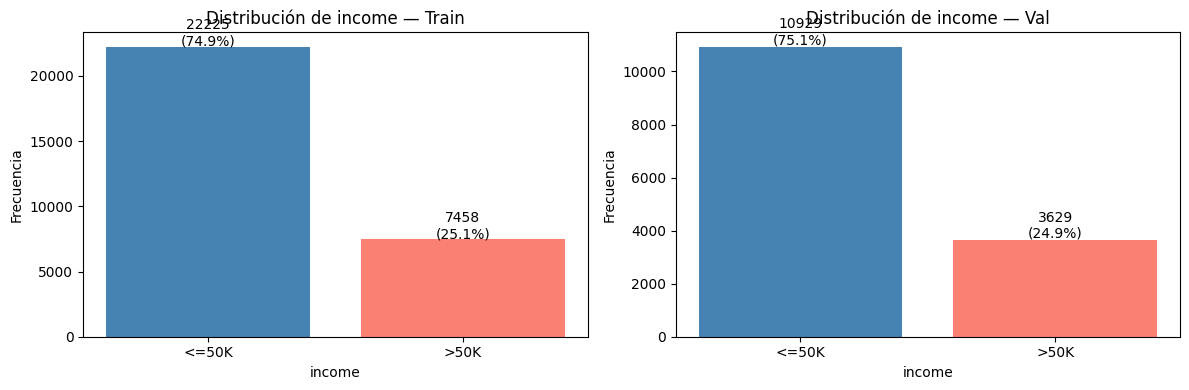

In [12]:
# Distribución del target en train y val
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, name) in zip(axes, [(df_train, "Train"), (df_val, "Val")]):
    counts = df["income"].value_counts()
    ax.bar(counts.index, counts.values, color=["steelblue", "salmon"])
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
    ax.set_title(f"Distribución de income — {name}")
    ax.set_xlabel("income")
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

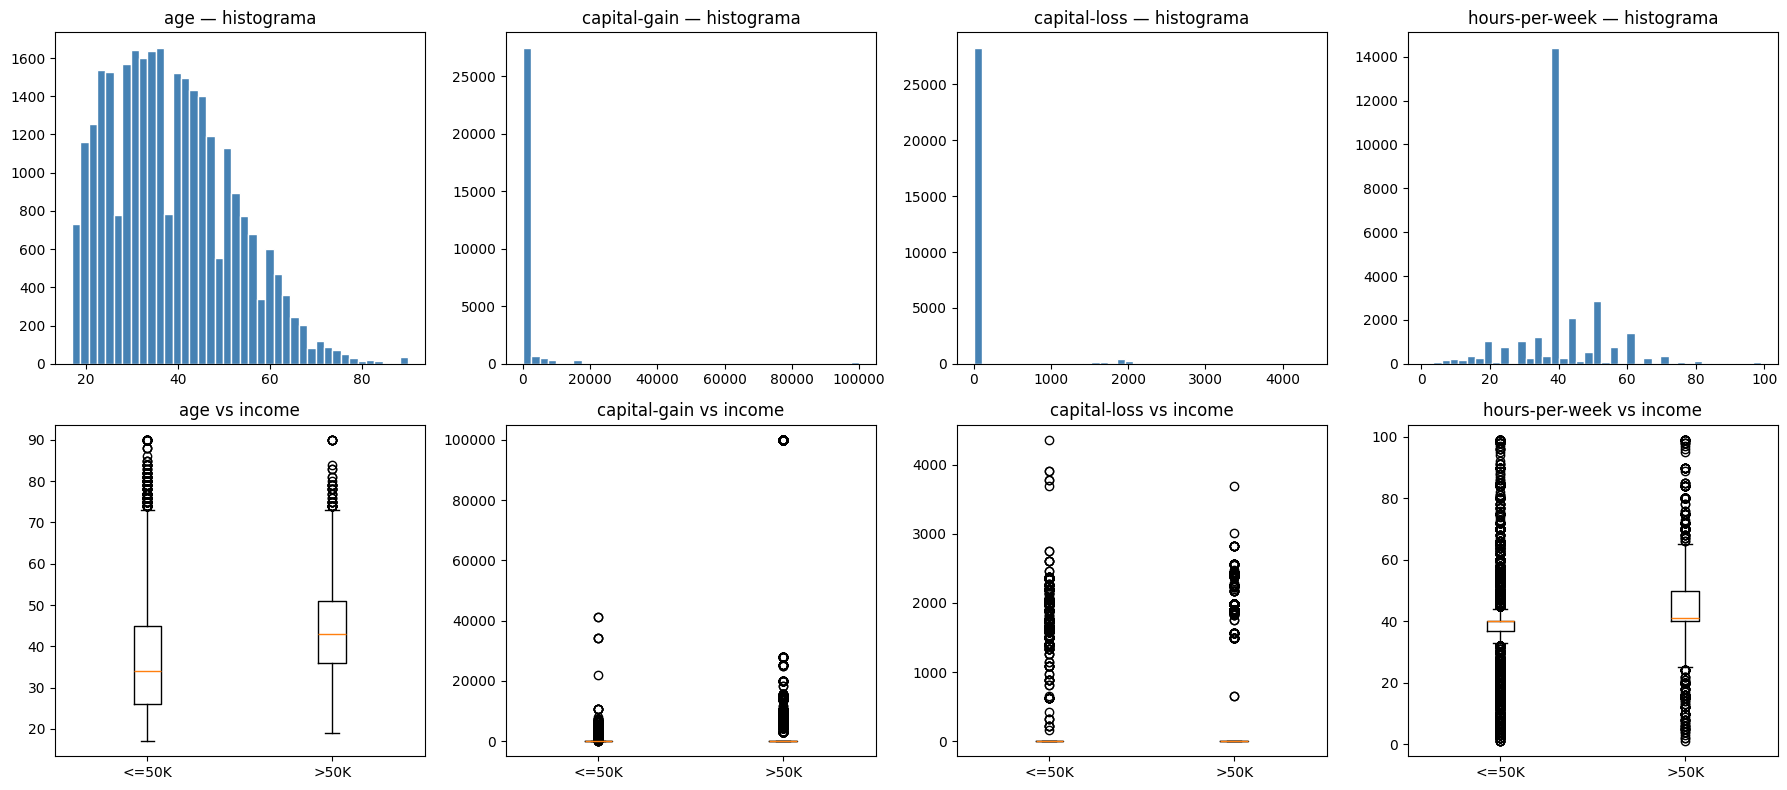

,age,capital-gain,capital-loss,hours-per-week
count,29683.000000,29683.000000,29683.000000,29683.000000
mean,38.546744,1109.629788,89.798572,40.991645
std,13.130225,7464.558413,407.390396,12.015810
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [13]:
num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df_train[col], bins=40, color="steelblue", edgecolor="white")
    axes[0, i].set_title(f"{col} — histograma")
    # Box plot by target
    groups = [df_train[df_train["income"] == cat][col] for cat in ["<=50K", ">50K"]]
    axes[1, i].boxplot(groups, tick_labels=["<=50K", ">50K"])
    axes[1, i].set_title(f"{col} vs income")
plt.tight_layout()
plt.show()

df_train[num_cols].describe()

De esto vemos lo siguiente:

- `Age` nos muestra algo común, a mayor edad la gente deja de trabajar. En el box plot vemos que personas con mayor edad consistentemente tienen mejores ingresos. Para <50k la mediana es 33 y >50k es 44.
- `capital-gain`. y `capital-loss` están bastante dominadas por ceros haciendo que el histograma y box plots sean un poco ilegibles. Lo que si podemos observar es que a mayor `capital_gain` pues mayores ingresos hay.


## Distribuciones


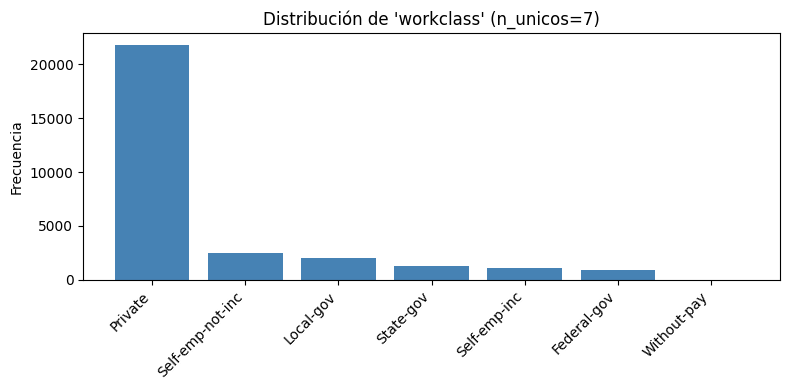

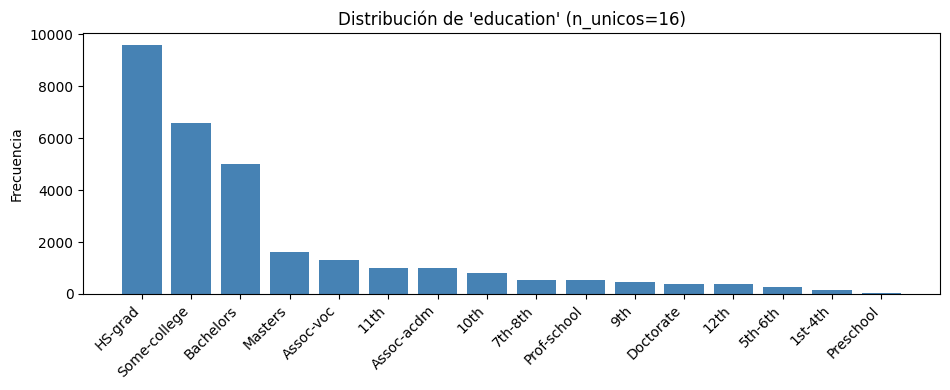

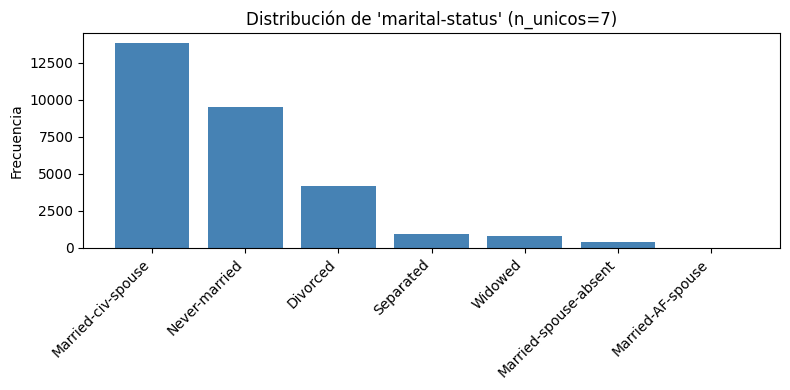

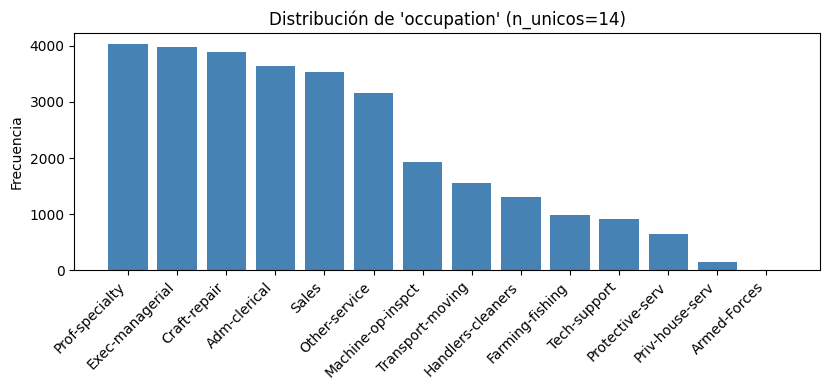

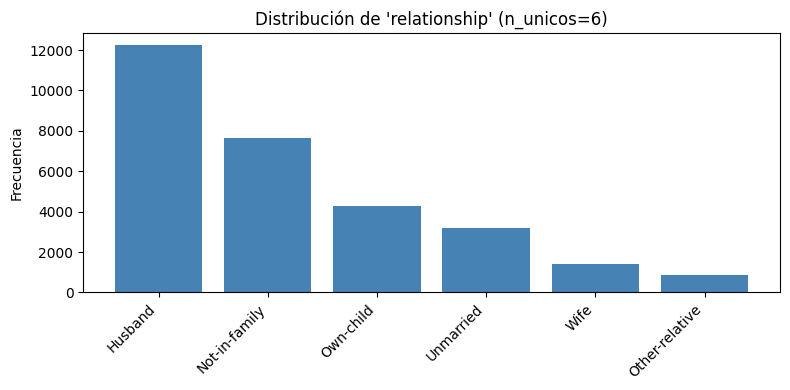

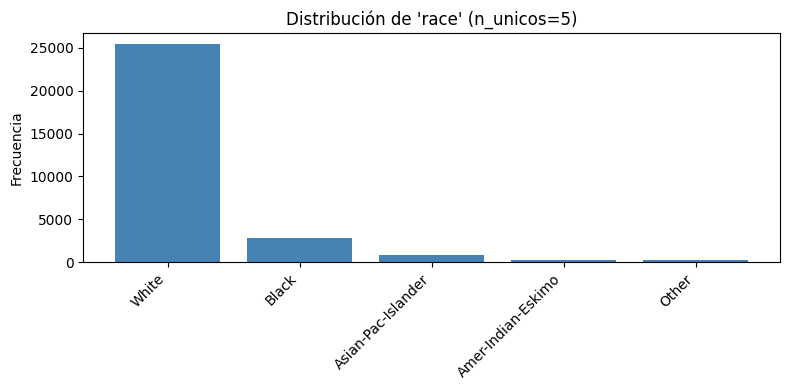

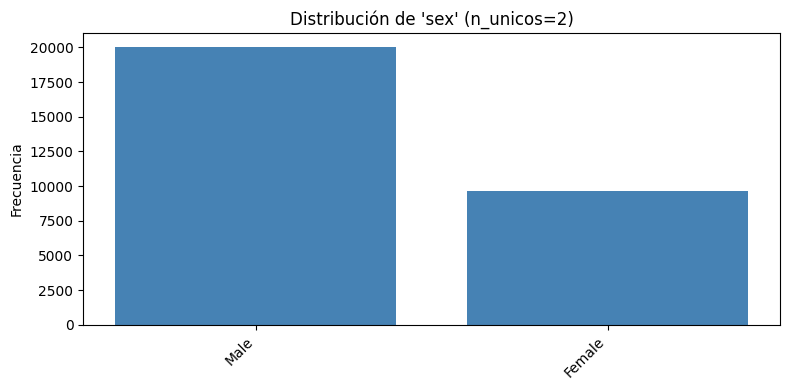

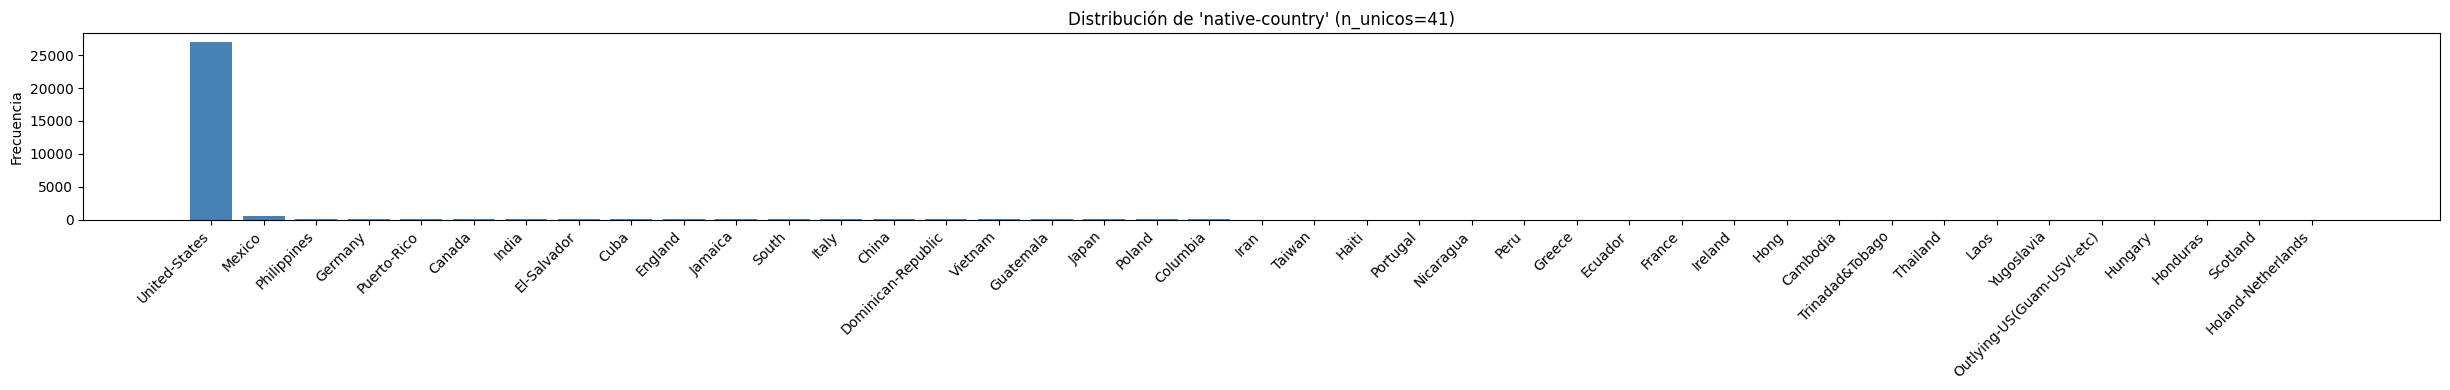

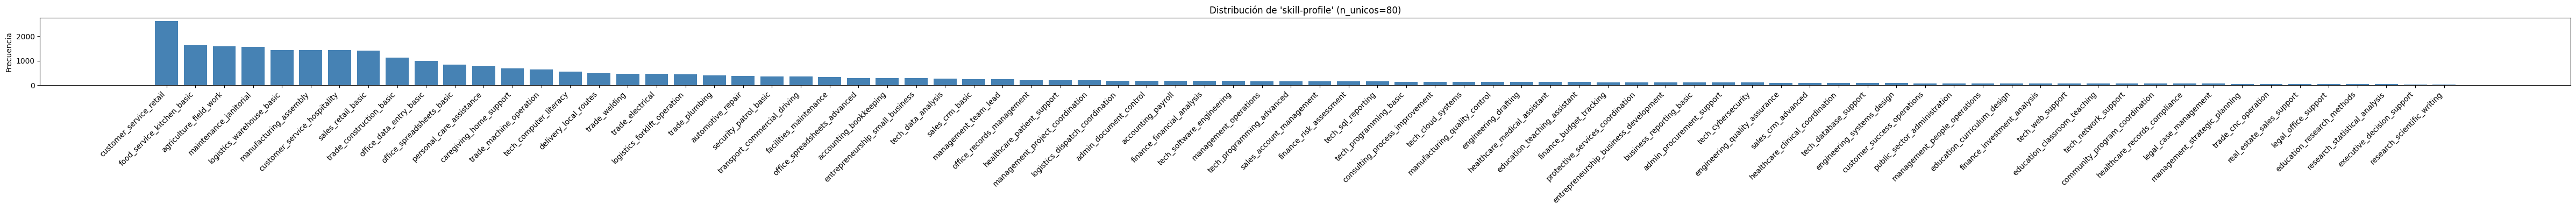

In [14]:
cat_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "skill-profile",
]


for col in cat_cols:
    vc = df_train[col].value_counts()
    fig, ax = plt.subplots(figsize=(max(8, len(vc) * 0.6), 4))
    ax.bar(range(len(vc)), vc.values, color="steelblue")
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=45, ha="right")
    ax.set_title(f"Distribución de '{col}' (n_unicos={len(vc)})")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

## Proporcion de income con las columnas categóricas

Excluyo las de alta cardinalidad debido a que se vuelve ilegible.


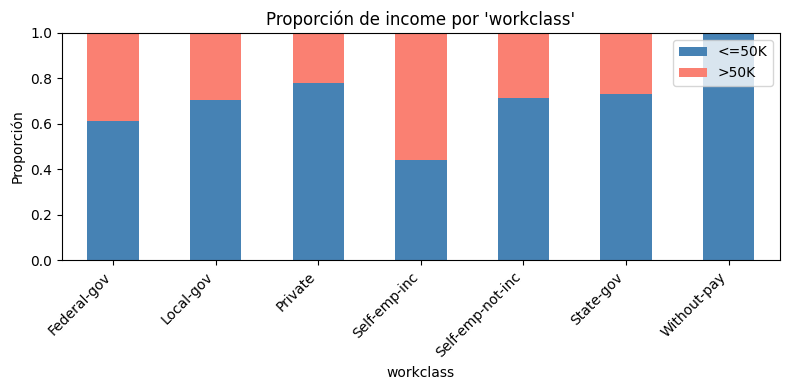

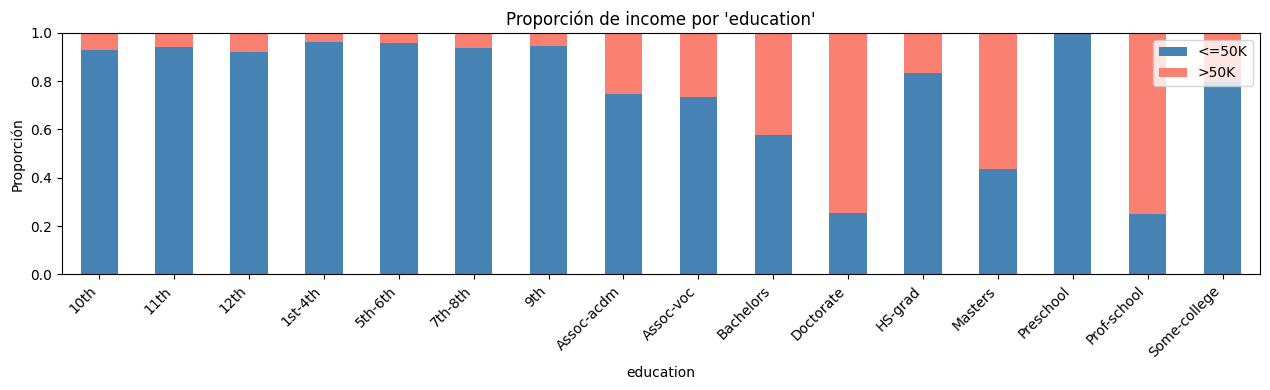

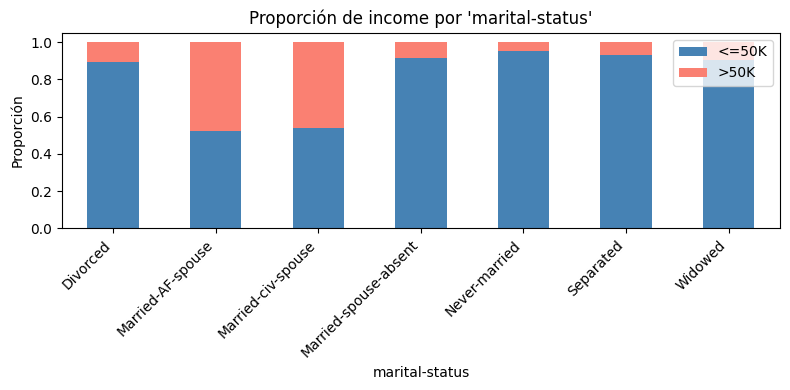

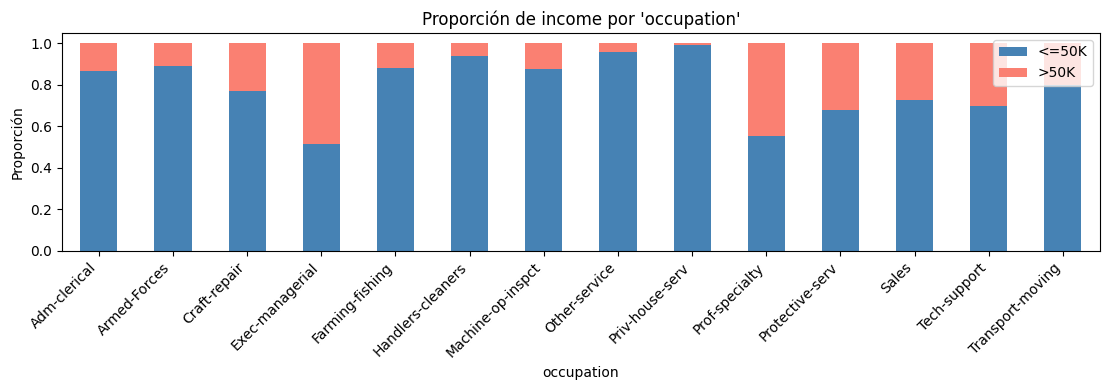

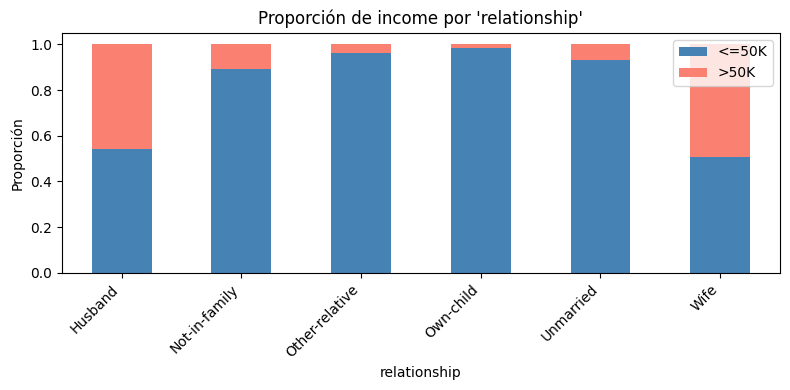

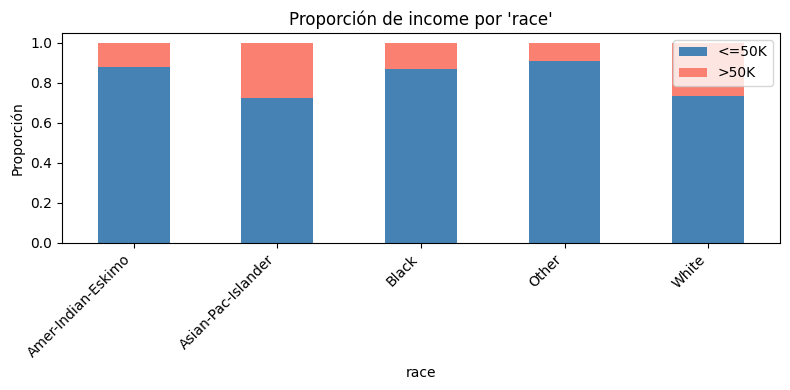

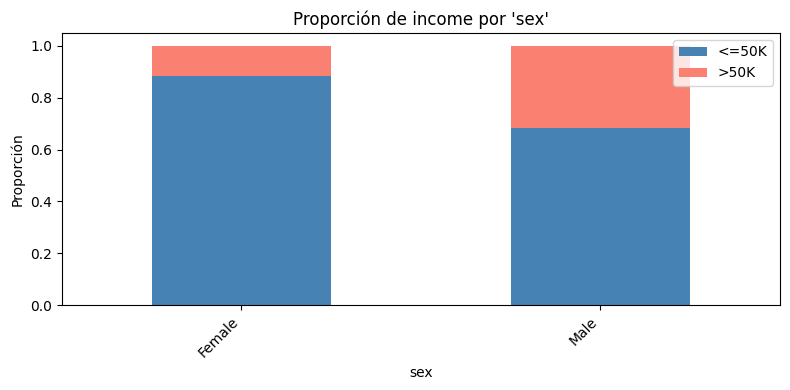

In [15]:
# Stacked bar: proportion of >50K per category
low_card_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
]

for col in low_card_cols:
    ct = pd.crosstab(df_train[col], df_train["income"], normalize="index")
    ct.plot(
        kind="bar",
        stacked=True,
        figsize=(max(8, len(ct) * 0.8), 4),
        color=["steelblue", "salmon"],
    )
    plt.title(f"Proporción de income por '{col}'")
    plt.ylabel("Proporción")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

Veamos un poco las categoricas con mayor cardinalidad, solo 15 para mantener legible las gráficas.


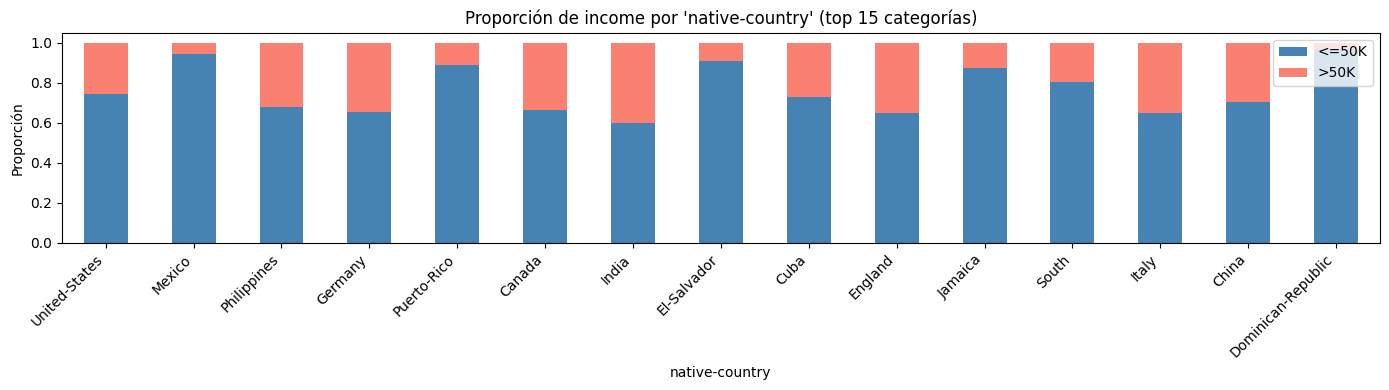

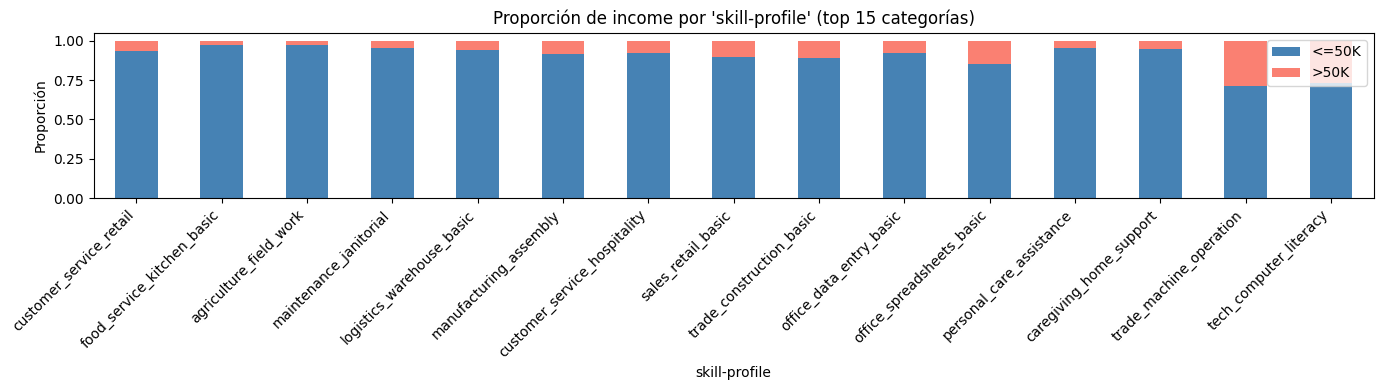

In [16]:
for col in ["native-country", "skill-profile"]:
    top15 = df_train[col].value_counts().index[:15]
    ct = pd.crosstab(df_train[col], df_train["income"], normalize="index")
    ct = ct.loc[top15]
    ct.plot(kind="bar", stacked=True, figsize=(14, 4), color=["steelblue", "salmon"])
    plt.title(f"Proporción de income por '{col}' (top 15 categorías)")
    plt.ylabel("Proporción")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

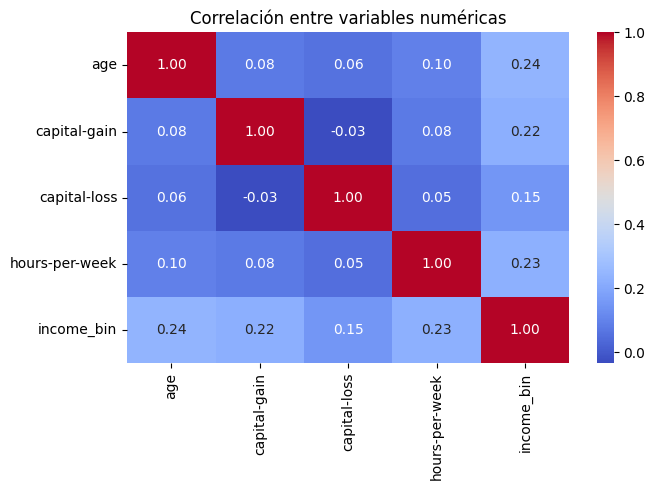

In [17]:
import seaborn as sns

corr = df_train[num_cols + ["income"]].copy()
corr["income_bin"] = (corr["income"] == ">50K").astype(int)
corr = corr.drop(columns="income")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

`age` es el predictor númerico mas fuerte aunque no tan alto.
`capital-gain` tiene una correlación alta pero recordemos que está dominado por el valor 0.

Tenemos correlaciones bajas


capital-gain: 27145 ceros (91.4%)


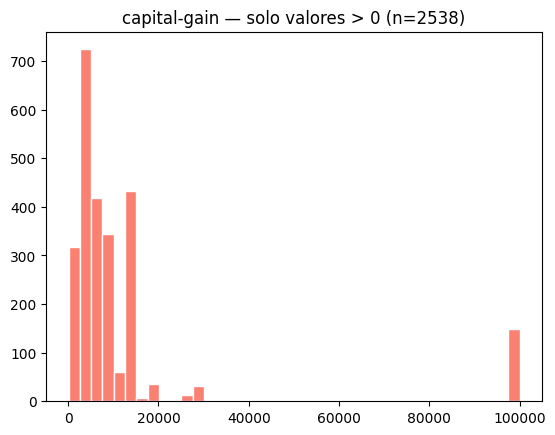

capital-loss: 28256 ceros (95.2%)


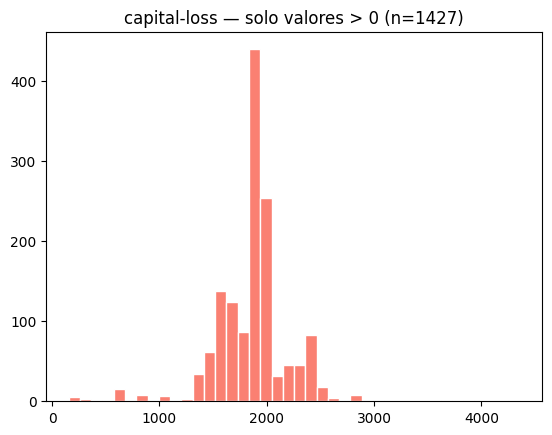

In [18]:
for col in ["capital-gain", "capital-loss"]:
    zeros = (df_train[col] == 0).sum()
    pct = zeros / len(df_train) * 100
    print(f"{col}: {zeros} ceros ({pct:.1f}%)")
    nonzero = df_train[df_train[col] > 0][col]
    plt.hist(nonzero, bins=40, color="salmon", edgecolor="white")
    plt.title(f"{col} — solo valores > 0 (n={len(nonzero)})")
    plt.show()

Aproximadamente el 9% de los registros reporta capital gains y un 5% perdidas. Tenemos un rango bastante alto. Una transformación logaritmica podria mejorar la señal de estas dos variables.


## Encodings


### Decisiones de transformación


#### Variables numéricas

- **age** - StandardScaler
  La distribución es continua y aproximadamente normal (pico en 30–35 con cola hacia 80+). No requiere transformación previa al escalado.

- **capital-gain** - log(x+1) + StandardScaler
  El 91% de los registros tiene valor 0. La distribución es fuertemente asimétrica con valores hasta$99,999. Sin transformación, StandardScaler produciría una media casi 0 y desviación estándar altísima. El log(x+1) comprime la escala antes de normalizar.

- **capital-loss** → log(x+1) + StandardScaler
  El 95% de los registros es 0. Misma problemática que capital-gain: la dominancia del cero distorsiona el escalado. Se aplica log(x+1) por la misma razón.

- **hours-per-week** → StandardScaler
  Distribución continua con pico pronunciado en 40 horas (jornada completa estándar). StandardScaler es suficiente.


In [19]:
from sklearn.preprocessing import StandardScaler

df_train_enc = df_train.copy()
df_val_enc = df_val.copy()


for col in ["capital-gain", "capital-loss"]:
    df_train_enc[col] = np.log1p(df_train_enc[col])
    df_val_enc[col] = np.log1p(df_val_enc[col])


num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]
scaler = StandardScaler()
df_train_enc[num_cols] = scaler.fit_transform(df_train_enc[num_cols])
df_val_enc[num_cols] = scaler.transform(df_val_enc[num_cols])

print("Numerical features scaled. Means (train, should be ~0):")
print(df_train_enc[num_cols].mean().round(4))

Numerical features scaled. Means (train, should be ~0):
age              -0.0
capital-gain      0.0
capital-loss     -0.0
hours-per-week   -0.0
dtype: float64


#### Variables categóricas binarias

- **sex** → Label encoding (Male=1, Female=0)
  Variable binaria.


In [20]:
df_train_enc["sex"] = (df_train_enc["sex"] == "Male").astype(int)
df_val_enc["sex"] = (df_val_enc["sex"] == "Male").astype(int)

print(df_train_enc["sex"].value_counts())

sex
1    20043
0     9640
Name: count, dtype: int64


#### Variables categóricas de baja cardinalidad — One-hot encoding

- **race** (5 categorías), **relationship** (6), **workclass** (7), **marital-status** (7)
  Estas variables son estrictamente nominales: no existe distancia ni jerarquía significativa entre sus categorías. El gráfico de proporciones muestra que cada categoría tiene un perfil de income distinto e independiente (por ejemplo, en `relationship`, "Husband" tiene ~45% >50K mientras "Own-child" tiene <5%). One-hot encoding preserva esta independencia correctamente, mientras que asignar enteros arbitrarios introduciría un orden artificial que el modelo podría malinterpretar. Con menos de 10 categorías cada una, el costo en dimensionalidad es manejable.


In [21]:
from sklearn.preprocessing import OneHotEncoder

ohe_cols = ["workclass", "marital-status", "relationship", "race"]
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", dtype=np.float32)
ohe.fit(df_train_enc[ohe_cols])

ohe_train = pd.DataFrame(
    ohe.transform(df_train_enc[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols)
)
ohe_val = pd.DataFrame(
    ohe.transform(df_val_enc[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols)
)

print(f"OHE output shape — train: {ohe_train.shape}, val: {ohe_val.shape}")
print("Columns:", list(ohe.get_feature_names_out(ohe_cols)))

OHE output shape — train: (29683, 25), val: (14558, 25)
Columns: ['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital-status_Divorced', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'relationship_Husband', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White']


#### Variable categórica de alta cardinalidad con orden — Ordinal encoding

- **education** (16 categorías) - Ordinal encoding
  A diferencia del resto de variables categóricas, `education` tiene un orden educativo universalmente reconocido (Preschool < 1st-4th < ... < Bachelors < Masters < Doctorate). El gráfico de proporciones confirma que este orden se alinea con el comportamiento del target: la proporción de >50K aumenta de forma general al subir en el nivel educativo (desde ~2% en Preschool hasta ~75% en Doctorate y Prof-school). Si bien la relación no es perfectamente monótona (Doctorate ≈ Prof-school, y hay individuos de bajo nivel educativo con altos ingresos), la tendencia general es clara.

  Sin embargo, hacer ordinal encoding requiere de tener conocimiento acerca del sistema educativo de donde se basa el dataset. Algunos niveles son facilmente reconocibles pero `Assoc-voc`, `Assoc-acdm` no dicen mucho a simple vista el nivel educativo en el que están. Además, `prof-school` no parece ser algo como más alto que `masters`, educativamente hablando. Por ende, el orden elegido en la siguiente cell puede estar sesgada por mi propia interpretación e investigación de estos niveles educativos y basados en los datos ya que `doctorate` y `prof-school` son similares en >50k ((visto en el EDA arriba)). Se deja como abierto a experimentar con embeddings en lugar de ordinal encoding para ver la diferencia en rendimiento del modelo.


In [22]:
from sklearn.preprocessing import LabelEncoder

EDUCATION_AS_EMBEDDING = False

if EDUCATION_AS_EMBEDDING:
    le_education = LabelEncoder()
    df_train_enc["education"] = le_education.fit_transform(df_train_enc["education"])
    df_val_enc["education"] = le_education.transform(df_val_enc["education"])
    print(f"education: embedding mode — {len(le_education.classes_)} índices")
else:
    education_order = [
        "Preschool",
        "1st-4th",
        "5th-6th",
        "7th-8th",
        "9th",
        "10th",
        "11th",
        "12th",
        "HS-grad",
        "Some-college",
        "Assoc-voc",
        "Assoc-acdm",
        "Bachelors",
        "Masters",
        "Prof-school",
        "Doctorate",
    ]
    edu_map = {cat: i for i, cat in enumerate(education_order)}
    df_train_enc["education"] = df_train_enc["education"].map(edu_map)
    df_val_enc["education"] = df_val_enc["education"].map(edu_map)
    assert (
        df_train_enc["education"].isna().sum() == 0
    ), "Unknown education category in train"
    assert (
        df_val_enc["education"].isna().sum() == 0
    ), "Unknown education category in val"
    print(
        f"education: ordinal mode — rango {df_train_enc['education'].min()}–{df_train_enc['education'].max()}"
    )

education: ordinal mode — rango 0–15


#### Variables categóricas de alta cardinalidad sin orden — Embeddings

- **occupation** (14 categorías) - Embedding
  El gráfico de proporciones muestra alta variabilidad en tasas de income entre ocupaciones. Las ocupaciones tienen proximidad semántica: categorías como "Exec-managerial" y "Prof-specialty" probablemente comparten un espacio de representación similar en términos de ingresos. Un embedding aprende representaciones densas que pueden capturar estas relaciones durante el entrenamiento.

- **native-country** (41 categorías) - Embedding
  La distribución es extremadamente desbalanceada: la gran mayoría de observaciones corresponden a "United-States", con decenas de países representados por muy pocas filas. One-hot generaría 41 columnas donde la mayoría son casi ceros, sin señal suficiente para aprender pesos útiles. En particular, "Holand-Netherlands" tiene un único registro en train y ninguno en val: dedicarle una columna entera con OHE es ineficiente. Los embeddings permiten que categorías raras compartan capacidad representacional con categorías similares, manejando mejor el desbalance de frecuencias.

- **skill-profile** (80 categorías) - Embedding
  Con 80 categorías únicas, OHE produciría 80 columnas binarias donde cada fila tendría 79 ceros y un solo 1 — el caso de uso exacto que los embeddings resuelven. Además, los perfiles de habilidad tienen agrupaciones semánticas naturales (e.g., `tech_programming_advanced` y `tech_programming_basic` deberían ser cercanos en el espacio de representación). Un embedding puede capturar estas similitudes.


In [23]:
from sklearn.preprocessing import LabelEncoder

emb_cols = ["occupation", "native-country", "skill-profile"]
label_encoders = {}

# Guardar strings originales antes de label encoding (necesario para OHE en sección c)
emb_strings_train = df_train_enc[emb_cols].copy()
emb_strings_val = df_val_enc[emb_cols].copy()

for col in emb_cols:
    le = LabelEncoder()
    df_train_enc[col] = le.fit_transform(df_train_enc[col])
    df_val_enc[col] = le.transform(df_val_enc[col])
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} categorías → índices 0–{len(le.classes_)-1}")

occupation: 14 categorías → índices 0–13
native-country: 41 categorías → índices 0–40
skill-profile: 80 categorías → índices 0–79


In [24]:
inplace_cols = [
    "age",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "sex",
    "education",
] + emb_cols


X_train = pd.concat(
    [
        df_train_enc[inplace_cols].reset_index(drop=True),
        ohe_train.reset_index(drop=True),
    ],
    axis=1,
)

X_val = pd.concat(
    [df_val_enc[inplace_cols].reset_index(drop=True), ohe_val.reset_index(drop=True)],
    axis=1,
)

# Binary target
y_train = (df_train_enc["income"] == ">50K").astype(int).reset_index(drop=True)
y_val = (df_val_enc["income"] == ">50K").astype(int).reset_index(drop=True)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(
    f"\nTarget distribution (train): {y_train.value_counts(normalize=True).mul(100).round(2).to_dict()}"
)

X_train: (29683, 34) | y_train: (29683,)
X_val:   (14558, 34) | y_val:   (14558,)

Target distribution (train): {0: 74.87, 1: 25.13}


Algo que no se ha mencionado es que tenemos un dataset moderadamente desbalanceado

Aproximadamente con 75% para <50K y 25% para >50k


In [25]:
assert X_train.isna().sum().sum() == 0, "NaN found in X_train"
assert X_val.isna().sum().sum() == 0, "NaN found in X_val"
assert X_train.shape[1] == X_val.shape[1], "Column mismatch between train and val"
assert set(y_train.unique()) == {0, 1}, "Target is not binary"
print("All assertions passed.")

All assertions passed.


## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.


### Dataset


In [26]:
import torch
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
# Nota: cudnn.deterministic solo aplica a CUDA, no a MPS (Apple Silicon).
# En MPS algunas operaciones siguen siendo no-deterministas por limitaciones del backend.

emb_col_names = ["occupation", "native-country", "skill-profile"]
if EDUCATION_AS_EMBEDDING:
    emb_col_names = emb_col_names + ["education"]

dense_col_names = [c for c in X_train.columns if c not in emb_col_names]


class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X_dense = torch.tensor(X[dense_col_names].values, dtype=torch.float32)
        self.X_occ = torch.tensor(X["occupation"].values, dtype=torch.long)
        self.X_country = torch.tensor(X["native-country"].values, dtype=torch.long)
        self.X_skill = torch.tensor(X["skill-profile"].values, dtype=torch.long)
        self.X_edu = torch.tensor(X["education"].values, dtype=torch.long)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return (
            self.X_dense[index],
            self.X_occ[index],
            self.X_country[index],
            self.X_skill[index],
            self.X_edu[index],
            self.y[index],
        )


train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)

# generator fijo para que el shuffle sea reproducible entre re-runs
_g = torch.Generator()
_g.manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, generator=_g)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(
    f"Dense features: {len(dense_col_names)} | education as embedding: {EDUCATION_AS_EMBEDDING}"
)

Train batches: 58 | Val batches: 29
Dense features: 31 | education as embedding: False


### Diseño del modelo


Las dimensiones de mis embeddings elijo algo empirico como `cardinalidad // 2`. Estos hiperparametros lo dejo abierto a experimenticación dependiendo del rendimiento del modelo.

Por ejemplo en un blog de tensorflow se menciona esto

https://developers.googleblog.com/introducing-tensorflow-feature-columns/
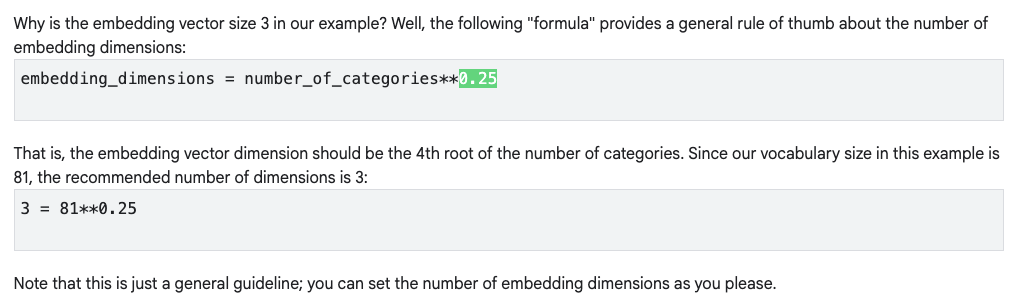

#### Arquitectura del modelo inicial

2 capas ocultas + 1 capa de salida, con anchos decrecientes 99 - 128 - 64 - 1

- Capa 1 - Linear(99 - 128), activación Relu, Dropout(0.3)
- Capa 2 - Linear(128 - 64), activación Relu, Dropout(0.3)
- Capa de salida - Linear(64 - 1), sin activación

Se elige esta arquitectura inicial de 2 capas ocultas. Si el modelo underfitea, probamos con más capas.


In [27]:
import torch.nn as nn
import torch.nn.functional as F


class IncomeModelEmbedding(nn.Module):
    def __init__(self):
        super().__init__()

        self.emb_occ = nn.Embedding(14, 7)
        self.emb_country = nn.Embedding(41, 21)
        self.emb_skill = nn.Embedding(80, 40)

        if EDUCATION_AS_EMBEDDING:
            self.emb_edu = nn.Embedding(16, 8)
            fc1_input = len(dense_col_names) + 7 + 21 + 40 + 8  # 106
        else:
            self.emb_edu = None
            fc1_input = len(dense_col_names) + 7 + 21 + 40  # 99

        self.fc1 = nn.Linear(fc1_input, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x_dense, x_occ, x_country, x_skill, x_edu):
        e_occ = self.emb_occ(x_occ)
        e_country = self.emb_country(x_country)
        e_skill = self.emb_skill(x_skill)

        parts = [x_dense, e_occ, e_country, e_skill]
        if EDUCATION_AS_EMBEDDING:
            parts.append(self.emb_edu(x_edu))

        x = torch.cat(parts, dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = IncomeModelEmbedding().to(device)
print(model)
print("device", device)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

IncomeModelEmbedding(
  (emb_occ): Embedding(14, 7)
  (emb_country): Embedding(41, 21)
  (emb_skill): Embedding(80, 40)
  (fc1): Linear(in_features=99, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
device mps

Total parameters: 25,280


### Entrenamiento

Debido a la naturaleza del problema cuyo target es binario se usa `BCEWithLogitsLoss` como función de costo.

Aqui haremos dos experimentos debido a que tenemos un problema desbalanceado:

- Experimento 1: Entrenaremos un modelo sin ningun tratamiento de desbalance
- Experimento 2: Entrenaremos un segundo modelo con `pos_weight` de Pytorch


In [28]:
from sklearn.metrics import f1_score, accuracy_score


def plot_history(history, title=""):
    """Grafica acc, F1-macro y loss (si está disponible) vs epoch para train y val."""
    has_loss = "train_loss" in history and len(history["train_loss"]) > 0
    n = 3 if has_loss else 2
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

    for ax, (tr_key, val_key), ylabel in zip(
        axes[:2],
        [("train_acc", "val_acc"), ("train_f1", "val_f1")],
        ["Accuracy", "F1 Macro"],
    ):
        ax.plot(history[tr_key], label="Train")
        ax.plot(history[val_key], label="Val")
        ax.set_title(f"{ylabel} vs Epoch{' — ' + title if title else ''}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()

    if has_loss:
        axes[2].plot(history["train_loss"], label="Train")
        axes[2].plot(history["val_loss"], label="Val")
        axes[2].set_title(f"Loss vs Epoch{' — ' + title if title else ''}")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Loss")
        axes[2].legend()

    plt.tight_layout()
    plt.show()


def run_epoch(loader, model, criterion, optimizer, train=True):
    if train:
        model.train()
    else:
        model.eval()

    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.set_grad_enabled(train):
        for x_dense, x_occ, x_country, x_skill, x_edu, y in loader:
            x_dense = x_dense.to(device)
            x_occ = x_occ.to(device)
            x_country = x_country.to(device)
            x_skill = x_skill.to(device)
            x_edu = x_edu.to(device)
            y = y.to(device)

            logits = model(x_dense, x_occ, x_country, x_skill, x_edu).squeeze(1)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).detach().cpu().int().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.detach().cpu().int().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    avg_loss = total_loss / len(loader)
    return acc, f1, avg_loss


# --- Experimento 1: sin pos_weight ---
EPOCHS = 50

# Re-seed antes de instanciar el modelo para que los pesos iniciales sean reproducibles
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

model1 = IncomeModelEmbedding().to(device)
criterion1 = nn.BCEWithLogitsLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3)
history1 = {
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_loss": [],
    "val_loss": [],
}

for epoch in range(1, EPOCHS + 1):
    train_acc, train_f1, train_loss = run_epoch(
        train_loader, model1, criterion1, optimizer1, train=True
    )
    val_acc, val_f1, val_loss = run_epoch(
        val_loader, model1, criterion1, optimizer1, train=False
    )

    history1["train_acc"].append(train_acc)
    history1["val_acc"].append(val_acc)
    history1["train_f1"].append(train_f1)
    history1["val_f1"].append(val_f1)
    history1["train_loss"].append(train_loss)
    history1["val_loss"].append(val_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | Train acc={train_acc:.4f} f1={train_f1:.4f} loss={train_loss:.4f}"
            f" | Val acc={val_acc:.4f} f1={val_f1:.4f} loss={val_loss:.4f}"
        )

Epoch  10 | Train acc=0.8884 f1=0.8469 loss=0.2661 | Val acc=0.8825 f1=0.8433 loss=0.2735
Epoch  20 | Train acc=0.8928 f1=0.8537 loss=0.2524 | Val acc=0.8843 f1=0.8397 loss=0.2692
Epoch  30 | Train acc=0.8974 f1=0.8598 loss=0.2420 | Val acc=0.8838 f1=0.8381 loss=0.2735
Epoch  40 | Train acc=0.9016 f1=0.8656 loss=0.2323 | Val acc=0.8817 f1=0.8365 loss=0.2795
Epoch  50 | Train acc=0.9044 f1=0.8693 loss=0.2258 | Val acc=0.8801 f1=0.8360 loss=0.2931


Vemos que a partir de la epoch 20-30 f1 en val comienza a fluctuar y en algunas iteraciones bajar mientras que train sigue subiendo, lo que indica overfit. Siendo el valor mas alto en val alrededor de la epoch 40. Epochs con un maximo de 50 parece ser lo más razonable.

Este analisis lo hice primero probando con 200 epochs. Para la entrega se deja con 50


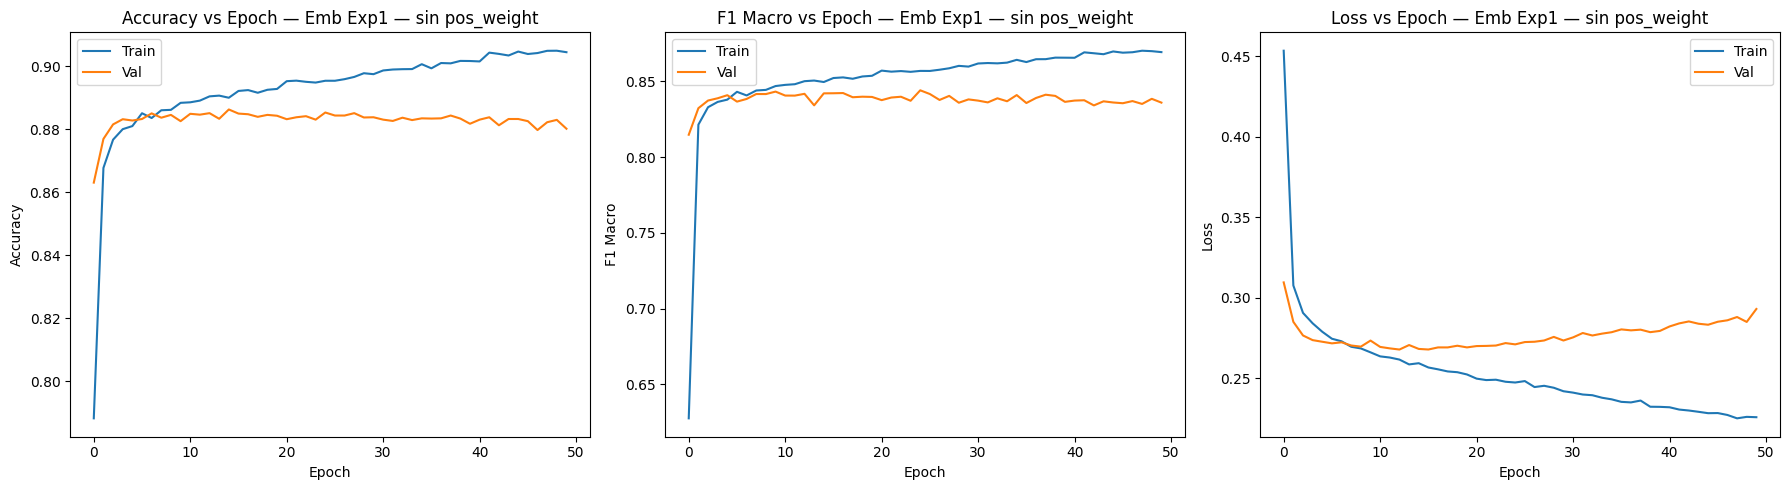

In [29]:
plot_history(history1, "Emb Exp1 — sin pos_weight")

              precision    recall  f1-score   support

       <=50K       0.91      0.93      0.92     10929
        >50K       0.78      0.72      0.75      3629

    accuracy                           0.88     14558
   macro avg       0.84      0.83      0.84     14558
weighted avg       0.88      0.88      0.88     14558



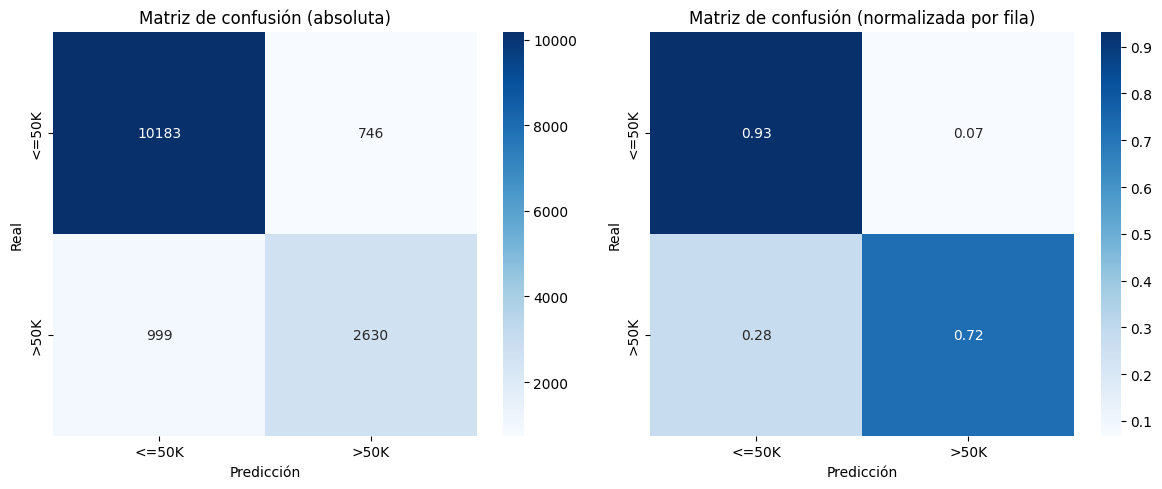

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model1.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_dense, x_occ, x_country, x_skill, x_edu, y in val_loader:
        logits = model1(
            x_dense.to(device),
            x_occ.to(device),
            x_country.to(device),
            x_skill.to(device),
            x_edu.to(device),
        ).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

### Nota: El SEED para torch por algun motivo no me funciona consistemente, a veces me da resultados de precision en >=50k entre 0.78 en >50k y 0.81, por ejemplo. Menciono esto ya que podría diferir los enunciados con lo que se ve en los resultados.

Hallé este github issue [Github issue - Pytorch](https://github.com/pytorch/pytorch/issues/97236) que sigue open asi que desconozco si esto es algo que sigue pendiente de arreglar para mps de Apple


### Resultados del experimento 1

Podemos ver que el modelo alcanza una accuracy de aproximadamente 88%, pero este número es engañoso debido a que estamos lidiando con un dataset moderadamente desbalanceado. Por ejemplo, un clasificador que predijera <=50k para todos obtendría un 75% aprox. de accuracy sin aprender nada. Tenemos los siguientes resultados:

- <=50k: 0.91 de precision, 0.93 de recall y 0.92 de F1. El modelo identifica correctamente el 93% de los individuos de esta clase. Tiene alto rendimiento con esta clase debido a que es la calse mayoritaria.
- \>=50k: 0.78 de precisión, 0.73 de recall y 0.75 de F1. El modelo falla en detectar un 27% de las personas que realmente ganan >50k, clasificandolos incorrectamente como <=50K (falso negativo).

Veamos el rendimiento usando `pos_weight` de Pytorch


### Experimento 2: con pos_weight (balance de clases)

Se repite el entrenamiento con `BCEWithLogitsLoss(pos_weight=neg/pos)` para penalizar más los errores en la clase minoritaria (>50K).


Epoch  10 | Train acc=0.8635 f1=0.8333 loss=0.4685 | Val acc=0.8397 f1=0.8097 loss=0.4821
Epoch  20 | Train acc=0.8685 f1=0.8395 loss=0.4410 | Val acc=0.8575 f1=0.8251 loss=0.4788
Epoch  30 | Train acc=0.8751 f1=0.8475 loss=0.4215 | Val acc=0.8575 f1=0.8256 loss=0.4910
Epoch  40 | Train acc=0.8778 f1=0.8508 loss=0.4029 | Val acc=0.8551 f1=0.8229 loss=0.5090
Epoch  50 | Train acc=0.8800 f1=0.8533 loss=0.3905 | Val acc=0.8531 f1=0.8203 loss=0.5373


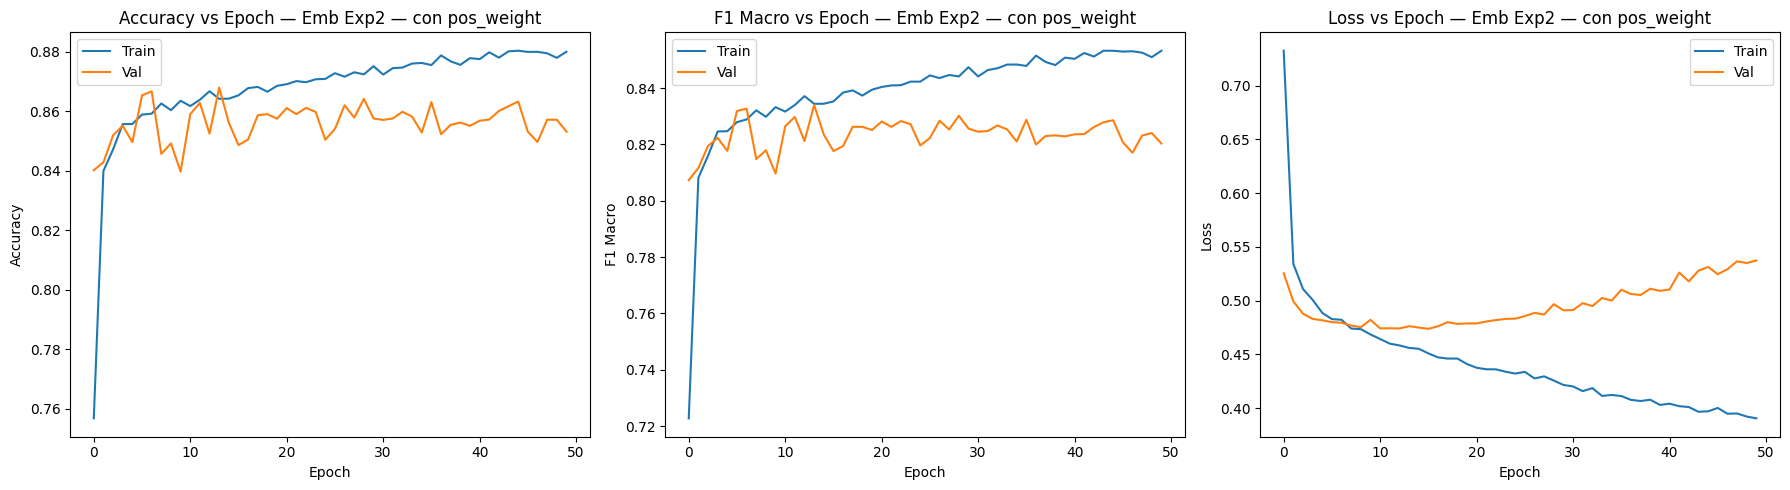

              precision    recall  f1-score   support

       <=50K       0.95      0.85      0.90     10929
        >50K       0.66      0.85      0.74      3629

    accuracy                           0.85     14558
   macro avg       0.80      0.85      0.82     14558
weighted avg       0.87      0.85      0.86     14558



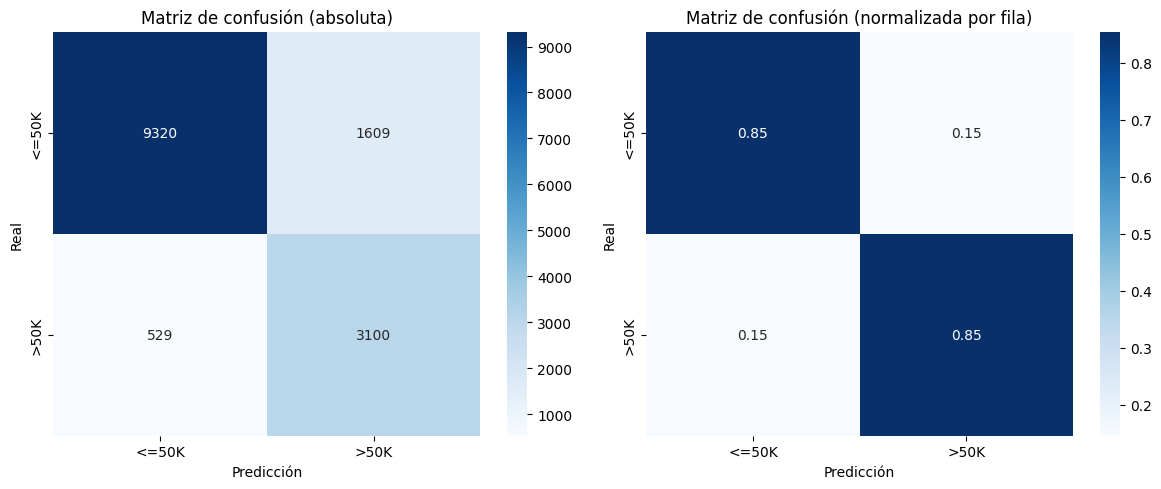

In [31]:
# --- Experimento 2: con pos_weight ---
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight_tensor = torch.tensor([neg / pos], dtype=torch.float32).to(device)

# Re-seed antes de instanciar model2 para que los pesos iniciales sean reproducibles
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
_g.manual_seed(SEED)  # reset shuffle order del DataLoader

model2 = IncomeModelEmbedding().to(device)
criterion2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
history2 = {
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_loss": [],
    "val_loss": [],
}

for epoch in range(1, EPOCHS + 1):
    train_acc, train_f1, train_loss = run_epoch(
        train_loader, model2, criterion2, optimizer2, train=True
    )
    val_acc, val_f1, val_loss = run_epoch(
        val_loader, model2, criterion2, optimizer2, train=False
    )

    history2["train_acc"].append(train_acc)
    history2["val_acc"].append(val_acc)
    history2["train_f1"].append(train_f1)
    history2["val_f1"].append(val_f1)
    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | Train acc={train_acc:.4f} f1={train_f1:.4f} loss={train_loss:.4f}"
            f" | Val acc={val_acc:.4f} f1={val_f1:.4f} loss={val_loss:.4f}"
        )

plot_history(history2, "Emb Exp2 — con pos_weight")

# Classification report + confusion matrices
model2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_dense, x_occ, x_country, x_skill, x_edu, y in val_loader:
        logits = model2(
            x_dense.to(device),
            x_occ.to(device),
            x_country.to(device),
            x_skill.to(device),
            x_edu.to(device),
        ).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

La métrica F1-score se redujo levemente a 0.82 (experimento 1 estaba en 0.84). Lo que indica que la capacidad total del modelo no cambió, solo penaliza más los errores en la clase minoritaria.

El recall de >50k mejoró por 13 (0.73 - 0.86): el modelo detecta ahora el 86% de las personas que realmente ganan >50k, reduciendo bastante los falsos negativos. Sin embargo, el tradeoff es una caída de 12 en precisión de >50k (0.78 - 0.66). El modelo es mejor prediciendo >50k pero genera más falsos positivos.

La elección entre ambos experimentos depende del caso de uso.


## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


Las 3 categorias que fueron representadas con embeddings, aqui las trataremos como OHE:

- occupation (14 - 14 columnas OHE)
- native-country (41 - 41 columnas OHE)
- skill-profile (80 - 80 columnas OHE)

El vector de entrada pasa de 99 a 166.

Se mantiene la misma arquitectura que en el modelo de embeddings, con la única diferencia de la dimensión del vector de entrada lo cual esta fuera de nuestras manos por el OHE

- Capa 1: Linear(166 - 128), activación ReLU
- Capa 2: Linear(128 - 64), activación ReLU
- Capa de salida: Linear(64 - 1)


In [32]:
# OHE para las columnas que eran embeddings en b)
ohe_c = OneHotEncoder(sparse_output=False, handle_unknown="ignore", dtype=np.float32)
ohe_c.fit(emb_strings_train)

ohe_c_train = pd.DataFrame(
    ohe_c.transform(emb_strings_train),
    columns=ohe_c.get_feature_names_out(emb_cols),
)
ohe_c_val = pd.DataFrame(
    ohe_c.transform(emb_strings_val),
    columns=ohe_c.get_feature_names_out(emb_cols),
)

# Las columnas densas de b) ya incluyen todas las demás features encodeadas
dense_c_cols = [c for c in X_train.columns if c not in emb_col_names]

X_train_c = pd.concat(
    [X_train[dense_c_cols].reset_index(drop=True), ohe_c_train.reset_index(drop=True)],
    axis=1,
)
X_val_c = pd.concat(
    [X_val[dense_c_cols].reset_index(drop=True), ohe_c_val.reset_index(drop=True)],
    axis=1,
)

print(f"X_train_c shape: {X_train_c.shape}")  # esperado: (N, 166)
print(f"X_val_c shape:   {X_val_c.shape}")

assert X_train_c.isna().sum().sum() == 0
assert X_val_c.isna().sum().sum() == 0
assert X_train_c.shape[1] == X_val_c.shape[1]
print("All assertions passed.")

X_train_c shape: (29683, 166)
X_val_c shape:   (14558, 166)
All assertions passed.


In [33]:
class MyDatasetOHE(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset_c = MyDatasetOHE(X_train_c, y_train)
val_dataset_c = MyDatasetOHE(X_val_c, y_val)

_g.manual_seed(SEED)
train_loader_c = DataLoader(train_dataset_c, batch_size=512, shuffle=True, generator=_g)
val_loader_c = DataLoader(val_dataset_c, batch_size=512, shuffle=False)

print(f"Train batches: {len(train_loader_c)} | Val batches: {len(val_loader_c)}")

Train batches: 58 | Val batches: 29


In [34]:
class IncomeModelOHE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


model_c = IncomeModelOHE(input_dim=X_train_c.shape[1]).to(device)
print(model_c)
print(f"\nTotal parameters: {sum(p.numel() for p in model_c.parameters()):,}")

IncomeModelOHE(
  (fc1): Linear(in_features=166, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 29,697


In [35]:
def run_epoch_ohe(loader, model, criterion, optimizer, train=True):
    if train:
        model.train()
    else:
        model.eval()

    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x).squeeze(1)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).detach().cpu().int().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.detach().cpu().int().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    avg_loss = total_loss / len(loader)
    return acc, f1, avg_loss

In [36]:
# Re-seed antes de instanciar model3 para que los pesos iniciales sean reproducibles
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
_g.manual_seed(SEED)  # reset shuffle order del DataLoader

# --- Experimento 1: sin pos_weight ---
model3 = IncomeModelOHE(input_dim=X_train_c.shape[1]).to(device)
criterion3 = nn.BCEWithLogitsLoss()
optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-3)
history3 = {
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_loss": [],
    "val_loss": [],
}

for epoch in range(1, EPOCHS + 1):
    train_acc, train_f1, train_loss = run_epoch_ohe(
        train_loader_c, model3, criterion3, optimizer3, train=True
    )
    val_acc, val_f1, val_loss = run_epoch_ohe(
        val_loader_c, model3, criterion3, optimizer3, train=False
    )

    history3["train_acc"].append(train_acc)
    history3["val_acc"].append(val_acc)
    history3["train_f1"].append(train_f1)
    history3["val_f1"].append(val_f1)
    history3["train_loss"].append(train_loss)
    history3["val_loss"].append(val_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | Train acc={train_acc:.4f} f1={train_f1:.4f} loss={train_loss:.4f}"
            f" | Val acc={val_acc:.4f} f1={val_f1:.4f} loss={val_loss:.4f}"
        )

Epoch  10 | Train acc=0.8907 f1=0.8515 loss=0.2526 | Val acc=0.8819 f1=0.8448 loss=0.2720
Epoch  20 | Train acc=0.8994 f1=0.8641 loss=0.2321 | Val acc=0.8838 f1=0.8432 loss=0.2745
Epoch  30 | Train acc=0.9108 f1=0.8794 loss=0.2106 | Val acc=0.8824 f1=0.8380 loss=0.2903
Epoch  40 | Train acc=0.9184 f1=0.8898 loss=0.1921 | Val acc=0.8761 f1=0.8225 loss=0.3251
Epoch  50 | Train acc=0.9247 f1=0.8982 loss=0.1786 | Val acc=0.8731 f1=0.8277 loss=0.3443


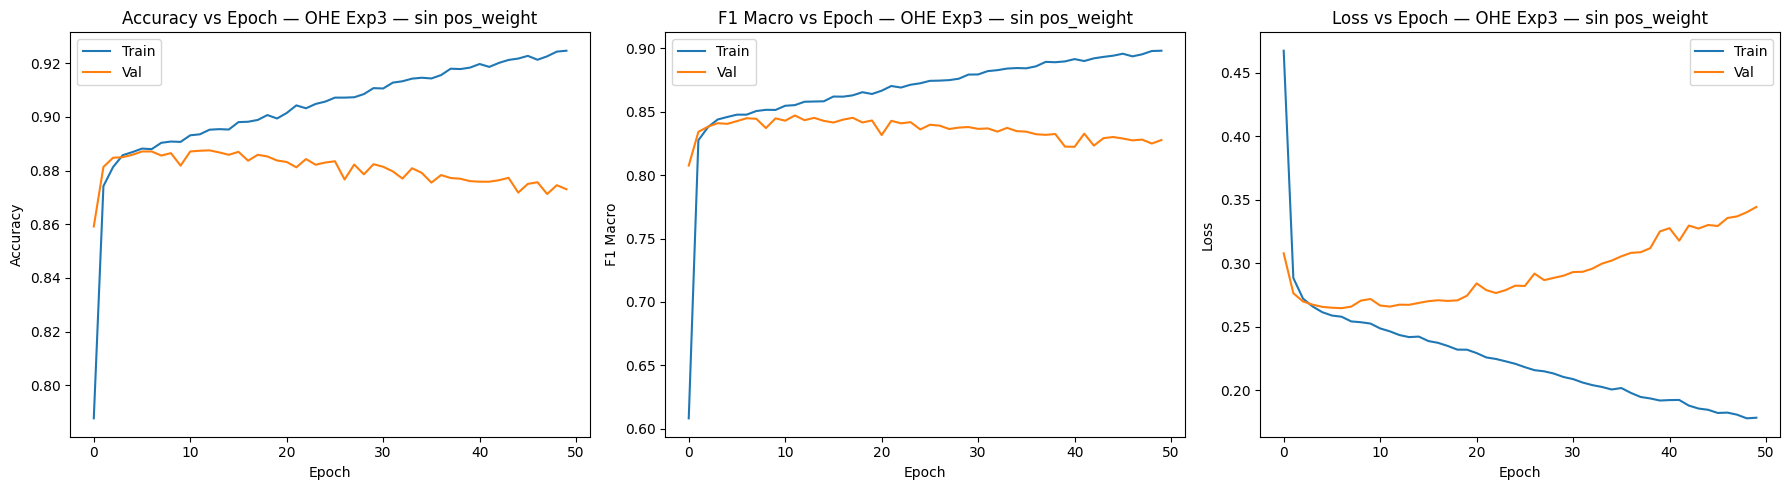

In [37]:
plot_history(history3, "OHE Exp3 — sin pos_weight")

              precision    recall  f1-score   support

       <=50K       0.91      0.92      0.92     10929
        >50K       0.76      0.72      0.74      3629

    accuracy                           0.87     14558
   macro avg       0.83      0.82      0.83     14558
weighted avg       0.87      0.87      0.87     14558



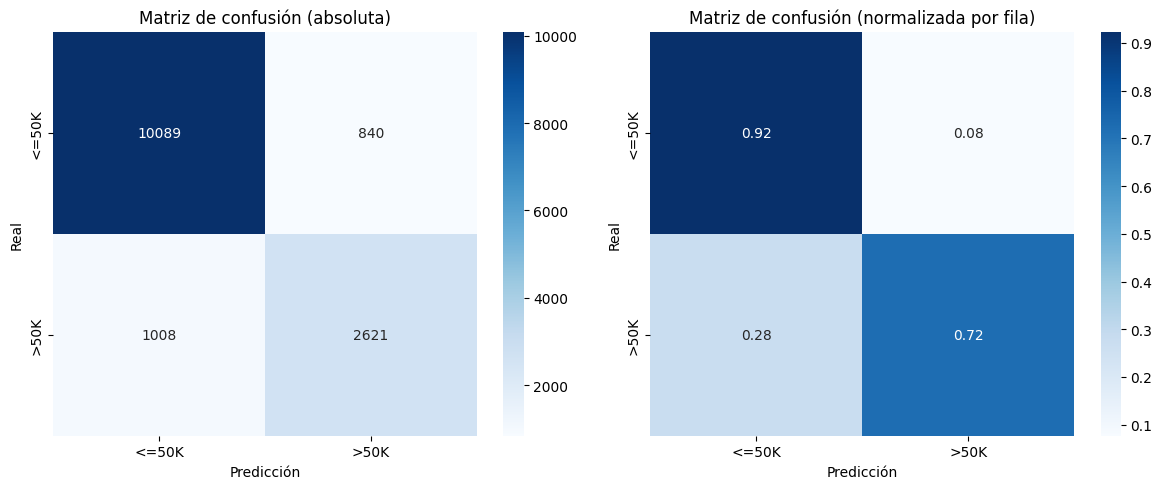

In [38]:
model3.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader_c:
        logits = model3(x.to(device)).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

### Resultados del modelo con OHE y experimento 1

El modelo obtuvo un rendimiento bastante similar al modelo de embeddings sin `pos_weight`.

- <=50k: 0.90 de precisión, 0.93 de recall y 0.92 de F1.
- \>=50k: 0.78 de precisión, 0.70 de recall y 0.73 de F1.

Los valores globales de F1 y accuracy andan bastante similar también, quiere decir que un modelo con OHE rinde igual de bien.

Veamos con el experimento 2.


Epoch  10 | Train acc=0.8666 f1=0.8377 loss=0.4426 | Val acc=0.8392 f1=0.8101 loss=0.4773
Epoch  20 | Train acc=0.8789 f1=0.8521 loss=0.4023 | Val acc=0.8579 f1=0.8260 loss=0.5003
Epoch  30 | Train acc=0.8881 f1=0.8628 loss=0.3698 | Val acc=0.8603 f1=0.8255 loss=0.5601
Epoch  40 | Train acc=0.8989 f1=0.8753 loss=0.3342 | Val acc=0.8673 f1=0.8275 loss=0.6810
Epoch  50 | Train acc=0.9066 f1=0.8843 loss=0.3056 | Val acc=0.8531 f1=0.8174 loss=0.7331


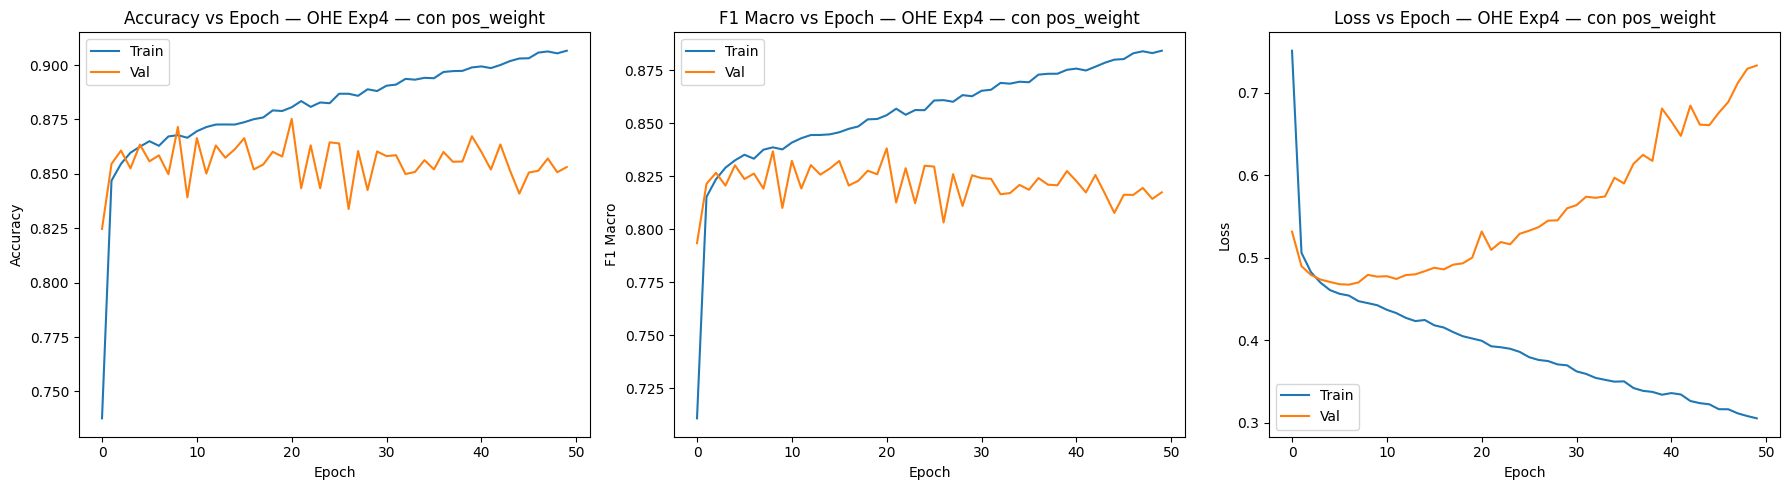

              precision    recall  f1-score   support

       <=50K       0.94      0.86      0.90     10929
        >50K       0.67      0.82      0.74      3629

    accuracy                           0.85     14558
   macro avg       0.80      0.84      0.82     14558
weighted avg       0.87      0.85      0.86     14558



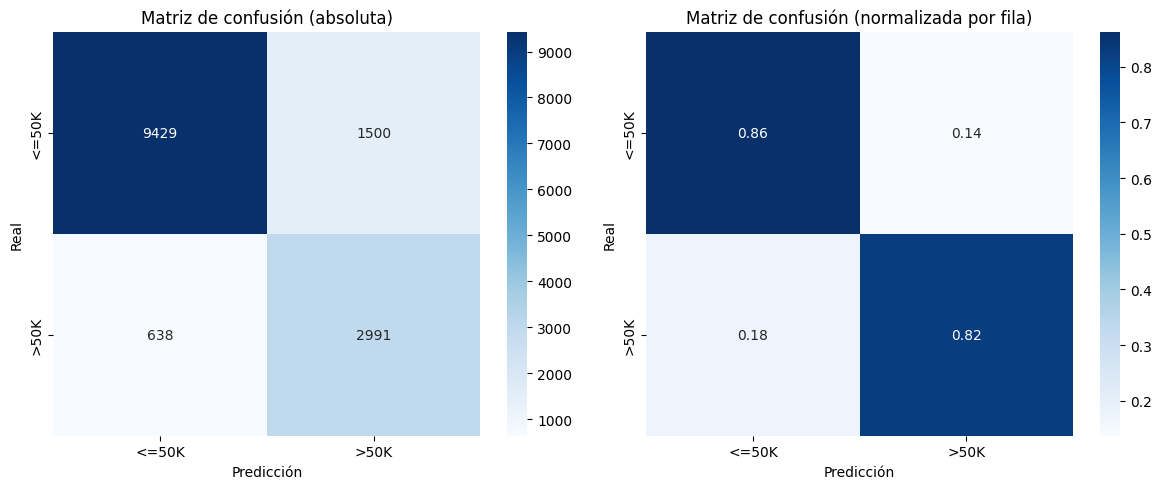

In [39]:
# Re-seed antes de instanciar model4 para que los pesos iniciales sean reproducibles
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
_g.manual_seed(SEED)  # reset shuffle order del DataLoader

# --- Experimento 2: con pos_weight ---
model4 = IncomeModelOHE(input_dim=X_train_c.shape[1]).to(device)
criterion4 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)  # reusar de b)
optimizer4 = torch.optim.Adam(model4.parameters(), lr=1e-3)
history4 = {
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_loss": [],
    "val_loss": [],
}

for epoch in range(1, EPOCHS + 1):
    train_acc, train_f1, train_loss = run_epoch_ohe(
        train_loader_c, model4, criterion4, optimizer4, train=True
    )
    val_acc, val_f1, val_loss = run_epoch_ohe(
        val_loader_c, model4, criterion4, optimizer4, train=False
    )

    history4["train_acc"].append(train_acc)
    history4["val_acc"].append(val_acc)
    history4["train_f1"].append(train_f1)
    history4["val_f1"].append(val_f1)
    history4["train_loss"].append(train_loss)
    history4["val_loss"].append(val_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | Train acc={train_acc:.4f} f1={train_f1:.4f} loss={train_loss:.4f}"
            f" | Val acc={val_acc:.4f} f1={val_f1:.4f} loss={val_loss:.4f}"
        )

plot_history(history4, "OHE Exp4 — con pos_weight")

# Classification report + confusion matrices
model4.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader_c:
        logits = model4(x.to(device)).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Se ven resultados bastante similares con el modelo de embeddings sin pos_weight. Alcanzando un rendimiento con diferencias despreciables. Aparece el mismo comportamiento que para >=50k se mejora el recall y F1-score pero se pierde un poco de precisión.

Algo que no se ha mencionado hasta el momento y lo cual es bastante visible en las gráficas de `loss vs epoch` es que se ve una tendencia clara de overfit. El loss en train sigue bajando a lo largo de las epochs mientras que val sigue subiendo.

Veamos unos experimentos para todos los modelos para regularizar mejor y reducir el overfitting.


## Experimento de regularización: weight decay + early stopping

Para la siguiente experimentación me base en diferentes recursos colocados sin orden:

- [Other Regularization Methods - Andrew Ng](https://www.youtube.com/watch?v=BOCLq2gpcGU&list=PLkDaE6sCZn6Hn0vK8co82zjQtt3T2Nkqc&index=8): De aqui obtuve la idea de Early Stopping, sin embargo Andrew NG menciona que esto podria tener un problema que él llama "Break the orthogonalization" que es basicamente un tuning que hagamos debe afectar una sola cosa: Reducir el costo o que no overfit. Con Early Stopping estamos deteniendo el training lo cual detiene ambas tareas, reducir el costo y el overfit, lo que tiene como consecuencia que no estamos minimizando el costo tan bien como podriamos. La alternativa que Andrew Ng recomienda es `L2 regularization` o `weight decay` ya que ambos se suelen llamar por esos nombres.

- [Red Neuronal Artificial (NN) - 16 - Regularización de L2 / Decaimiento de pesos (Teoría + código)](https://www.youtube.com/watch?v=_SlPBbxuqas): De aquí indague un poco más en la teoria de que L2 y weight decay son esencialmente lo mismo para SGD pero para Adam no, debido al funcionamiento de Adam con su historial de gradientes para actualizar los pesos, el weight decay lo rompe. Es por ello que se utiliza `AdamW`. Un poco simplificado pero para no extender tanto. Esto se profundiza en [DECOUPLED WEIGHT DECAY REGULARIZATION](https://scispace.com/pdf/decoupled-weight-decay-regularization-3pkyc25esh.pdf)

- [Dive into Deep Learning](https://d2l.ai/d2l-en.pdf): Aquí se menciona que L2 o weight decay por si solo no es capaz de detener que un modelo no haga overfit, eventualmente loss en val subirá. En la sección `5.5.4 Classical Regularization Methods for Deep Networks` se menciona que combinar L2 y early stopping es eficiente ya que L2 mejora la trayectoria del error mientras que Early Stopping detiene el overfit.

Para esta experimentación combinaré ambas técnicas, `L2` o `weight_decay` con `Early Stopping`

Los cuatro modelos anteriores (Exp1–Exp4) muestran un patrón claro de overfitting: la loss de entrenamiento sigue bajando de forma sostenida mientras que la loss de validación deja de mejorar alrededor del epoch 5–8 y luego empieza a subir (ver las gráficas de arriba). El modelo memoriza el set de entrenamiento en lugar de generalizar.

Para mitigarlo aplicamos **dos regularizadores en simultáneo**, manteniendo todo lo demás idéntico (misma arquitectura) para que cualquier mejora sea atribuible únicamente a la regularización:

- **Weight decay ** mediante `AdamW(..., weight_decay=1e-4)`: penaliza la magnitud de los pesos en cada paso, reduciendo la capacidad del modelo para memorizar y suavizando la frontera de decisión. Usamos `AdamW` —en lugar de `Adam` con una penalización L2 manual— porque desacopla correctamente el decay del paso adaptativo del optimizador.
- **Early stopping** sobre `val_loss` (`patience=7`): detiene el entrenamiento cuando la loss de validación deja de mejorar y restaura los pesos del mejor epoch, de modo que el modelo final no es el del epoch 50 (el más sobreajustado) sino el de mejor generalización.

Re-entrenamos las cuatro configuraciones (Embeddings y OHE, cada una con y sin `pos_weight`) y comparamos las curvas contra el baseline.


In [40]:
import copy

# Config de regularización compartida por los experimentos R1–R4
WEIGHT_DECAY = 1e-4  # L2 desacoplado en AdamW
PATIENCE = 7  # epochs sin mejora de val_loss antes de frenar


def fit_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    run_fn,
    epochs=50,
    patience=7,
    log_every=10,
):
    """Entrena con early stopping sobre val_loss y restaura los mejores pesos.

    `run_fn` es run_epoch (embeddings) o run_epoch_ohe (one-hot). Devuelve el
    history y deja el modelo cargado con los pesos del mejor epoch (no el ultimo).
    """
    history = {
        k: []
        for k in [
            "train_acc",
            "val_acc",
            "train_f1",
            "val_f1",
            "train_loss",
            "val_loss",
        ]
    }
    best_val = float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        tr_acc, tr_f1, tr_loss = run_fn(
            train_loader, model, criterion, optimizer, train=True
        )
        va_acc, va_f1, va_loss = run_fn(
            val_loader, model, criterion, optimizer, train=False
        )

        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(va_f1)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)

        if va_loss < best_val:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % log_every == 0:
            print(
                f"Epoch {epoch:3d} | Train acc={tr_acc:.4f} f1={tr_f1:.4f} loss={tr_loss:.4f}"
                f" | Val acc={va_acc:.4f} f1={va_f1:.4f} loss={va_loss:.4f}"
            )

        if bad_epochs >= patience:
            print(
                f"Early stopping en epoch {epoch} | mejor val_loss={best_val:.4f} @ epoch {best_epoch}"
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Pesos restaurados al mejor epoch ({best_epoch}, val_loss={best_val:.4f})")
    return history

Epoch  10 | Train acc=0.8881 f1=0.8466 loss=0.2663 | Val acc=0.8833 f1=0.8445 loss=0.2734
Epoch  20 | Train acc=0.8931 f1=0.8543 loss=0.2526 | Val acc=0.8847 f1=0.8406 loss=0.2693
Early stopping en epoch 23 | mejor val_loss=0.2680 @ epoch 16
Pesos restaurados al mejor epoch (16, val_loss=0.2680)


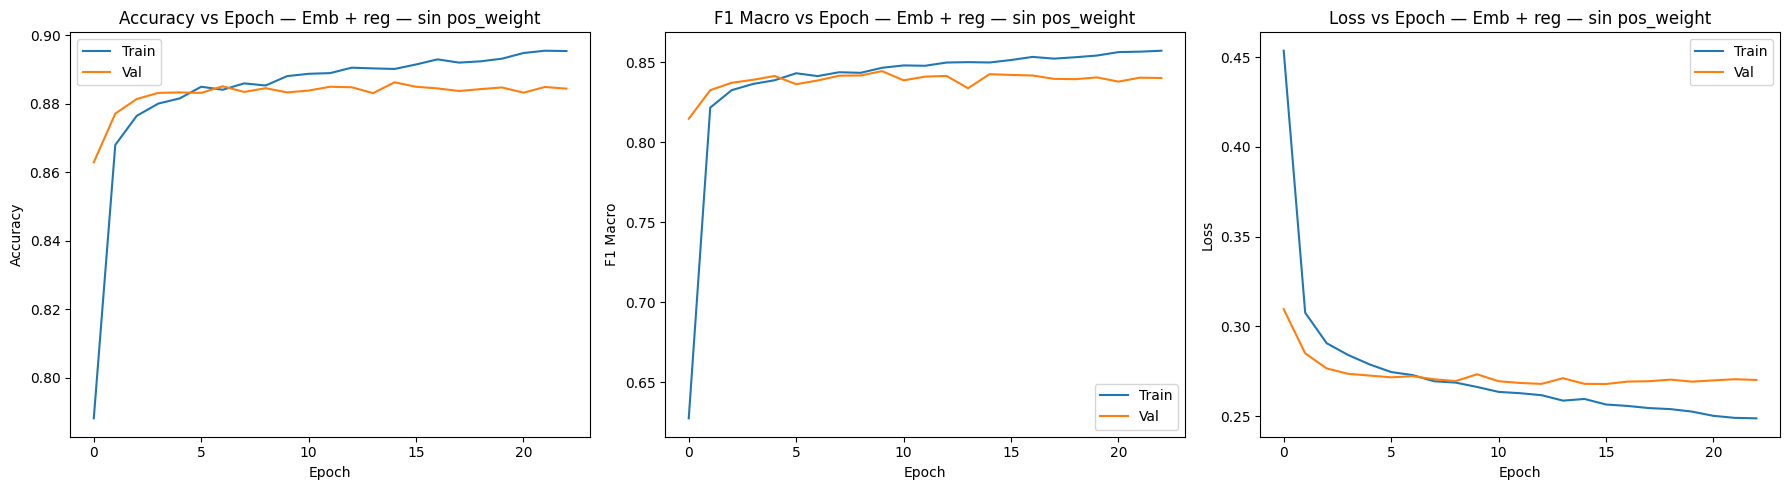

In [41]:
# === Experimento R1: Embeddings, sin pos_weight (weight decay + early stopping) ===
# Mismo SEED / shuffle que el Exp1 baseline: la unica diferencia es la regularizacion.
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
_g.manual_seed(SEED)  # reset shuffle order del DataLoader

model5 = IncomeModelEmbedding().to(device)
criterion5 = nn.BCEWithLogitsLoss()
optimizer5 = torch.optim.AdamW(model5.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)

history5 = fit_model(
    model5,
    criterion5,
    optimizer5,
    train_loader,
    val_loader,
    run_epoch,
    epochs=EPOCHS,
    patience=PATIENCE,
)
plot_history(history5, "Emb + reg — sin pos_weight")

              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.92     10929
        >50K       0.79      0.73      0.76      3629

    accuracy                           0.88     14558
   macro avg       0.85      0.83      0.84     14558
weighted avg       0.88      0.88      0.88     14558



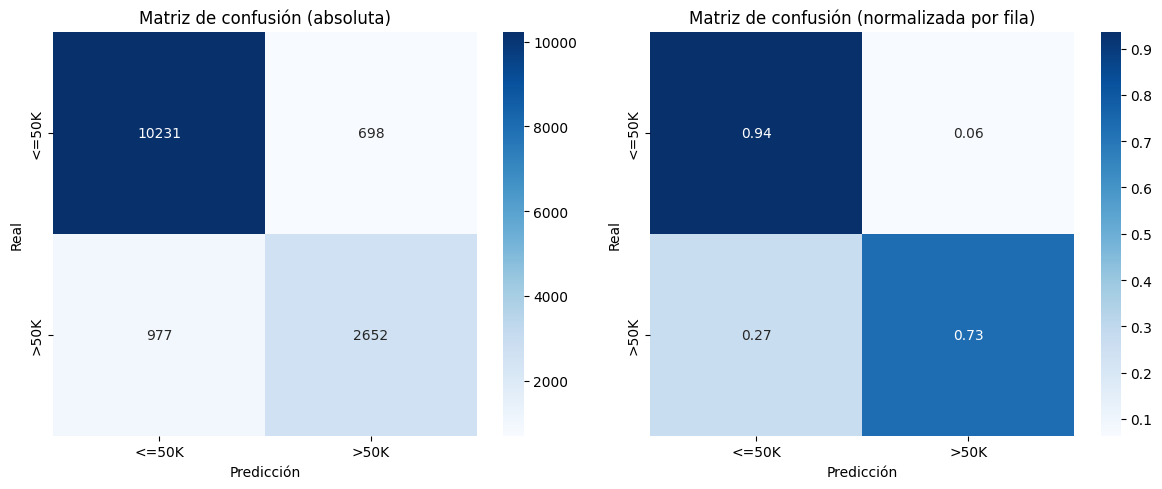

In [42]:
# Classification report + matrices de confusión — R1 (Embeddings, sin pos_weight)
model5.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_dense, x_occ, x_country, x_skill, x_edu, y in val_loader:
        logits = model5(
            x_dense.to(device),
            x_occ.to(device),
            x_country.to(device),
            x_skill.to(device),
            x_edu.to(device),
        ).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Epoch  10 | Train acc=0.8637 f1=0.8335 loss=0.4681 | Val acc=0.8404 f1=0.8101 loss=0.4810
Epoch  20 | Train acc=0.8676 f1=0.8383 loss=0.4406 | Val acc=0.8580 f1=0.8262 loss=0.4768
Early stopping en epoch 23 | mejor val_loss=0.4729 @ epoch 16
Pesos restaurados al mejor epoch (16, val_loss=0.4729)


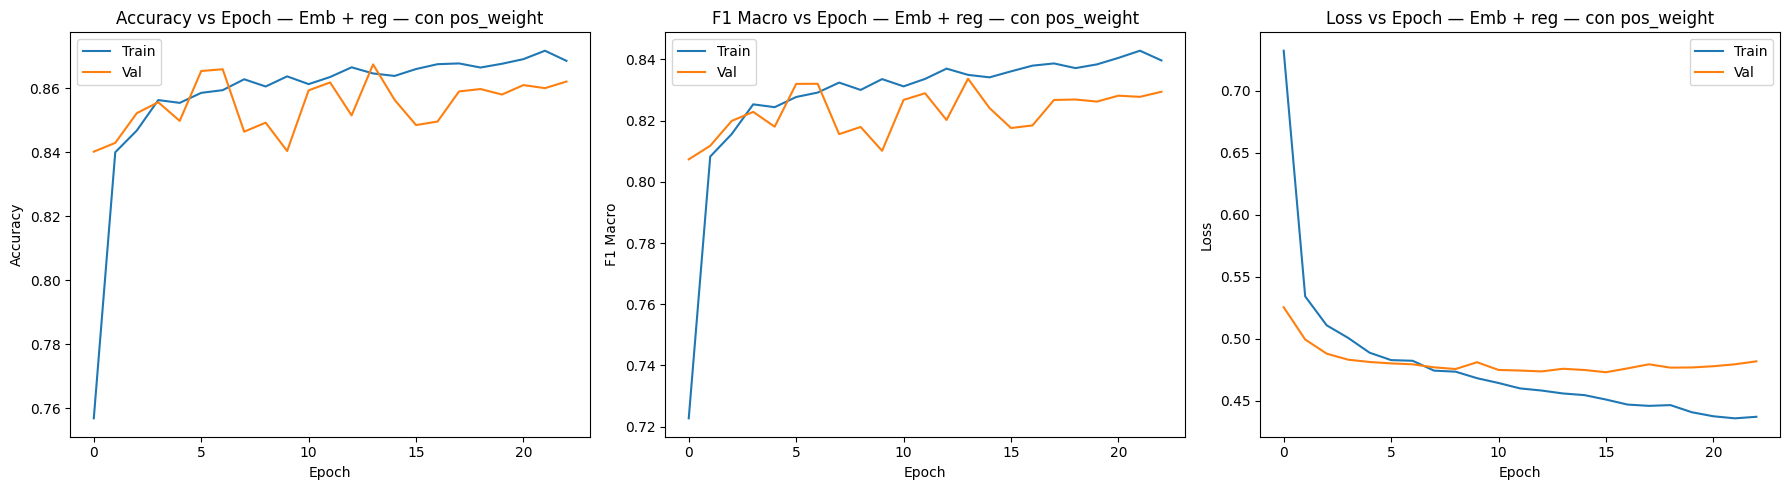

In [43]:
# === Experimento R2: Embeddings, con pos_weight (weight decay + early stopping) ===
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
_g.manual_seed(SEED)

model6 = IncomeModelEmbedding().to(device)
criterion6 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer6 = torch.optim.AdamW(model6.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)

history6 = fit_model(
    model6,
    criterion6,
    optimizer6,
    train_loader,
    val_loader,
    run_epoch,
    epochs=EPOCHS,
    patience=PATIENCE,
)
plot_history(history6, "Emb + reg — con pos_weight")

              precision    recall  f1-score   support

       <=50K       0.95      0.84      0.89     10929
        >50K       0.64      0.88      0.74      3629

    accuracy                           0.85     14558
   macro avg       0.80      0.86      0.82     14558
weighted avg       0.88      0.85      0.86     14558



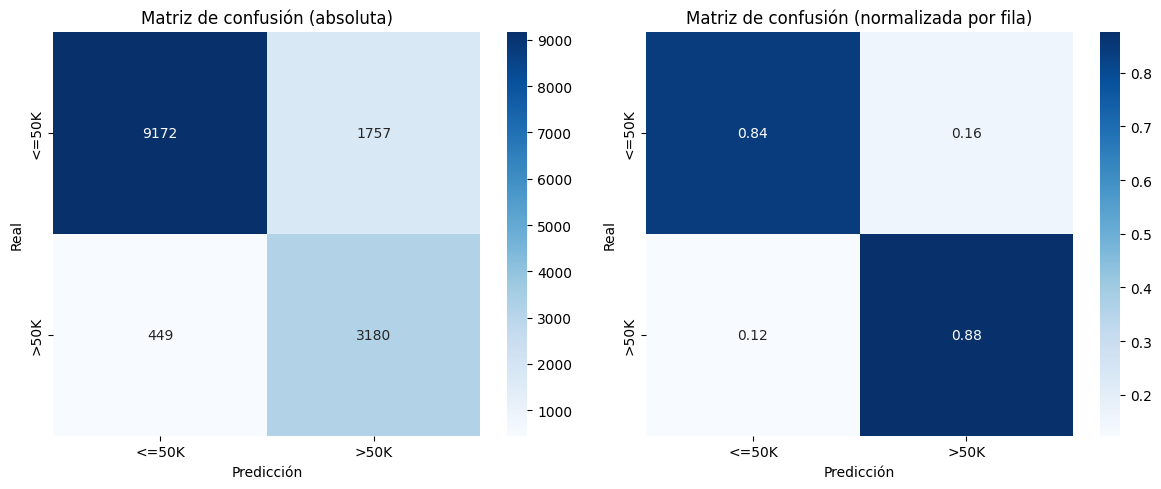

In [44]:
# Classification report + matrices de confusión — R2 (Embeddings, con pos_weight)
model6.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_dense, x_occ, x_country, x_skill, x_edu, y in val_loader:
        logits = model6(
            x_dense.to(device),
            x_occ.to(device),
            x_country.to(device),
            x_skill.to(device),
            x_edu.to(device),
        ).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Epoch  10 | Train acc=0.8907 f1=0.8515 loss=0.2529 | Val acc=0.8818 f1=0.8449 loss=0.2720
Early stopping en epoch 14 | mejor val_loss=0.2646 @ epoch 7
Pesos restaurados al mejor epoch (7, val_loss=0.2646)


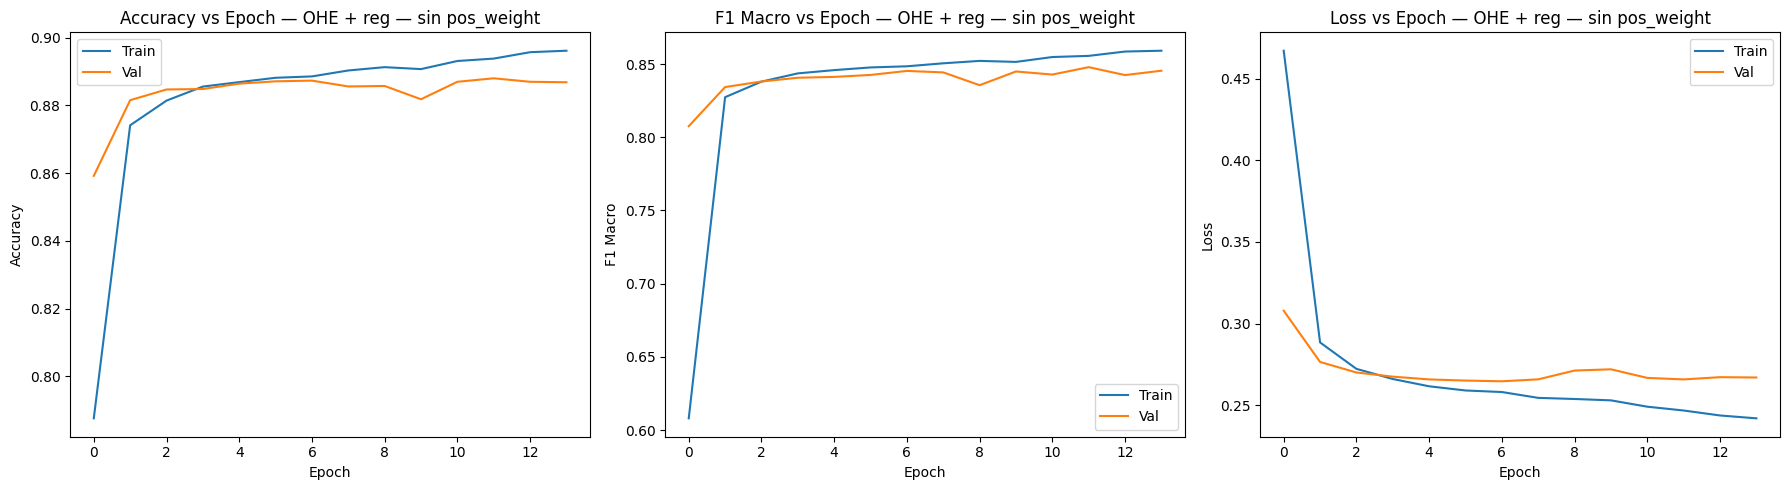

In [45]:
# === Experimento R3: OHE, sin pos_weight (weight decay + early stopping) ===
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
_g.manual_seed(SEED)

model7 = IncomeModelOHE(input_dim=X_train_c.shape[1]).to(device)
criterion7 = nn.BCEWithLogitsLoss()
optimizer7 = torch.optim.AdamW(model7.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)

history7 = fit_model(
    model7,
    criterion7,
    optimizer7,
    train_loader_c,
    val_loader_c,
    run_epoch_ohe,
    epochs=EPOCHS,
    patience=PATIENCE,
)
plot_history(history7, "OHE + reg — sin pos_weight")

              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.93     10929
        >50K       0.80      0.73      0.76      3629

    accuracy                           0.89     14558
   macro avg       0.86      0.84      0.85     14558
weighted avg       0.89      0.89      0.89     14558



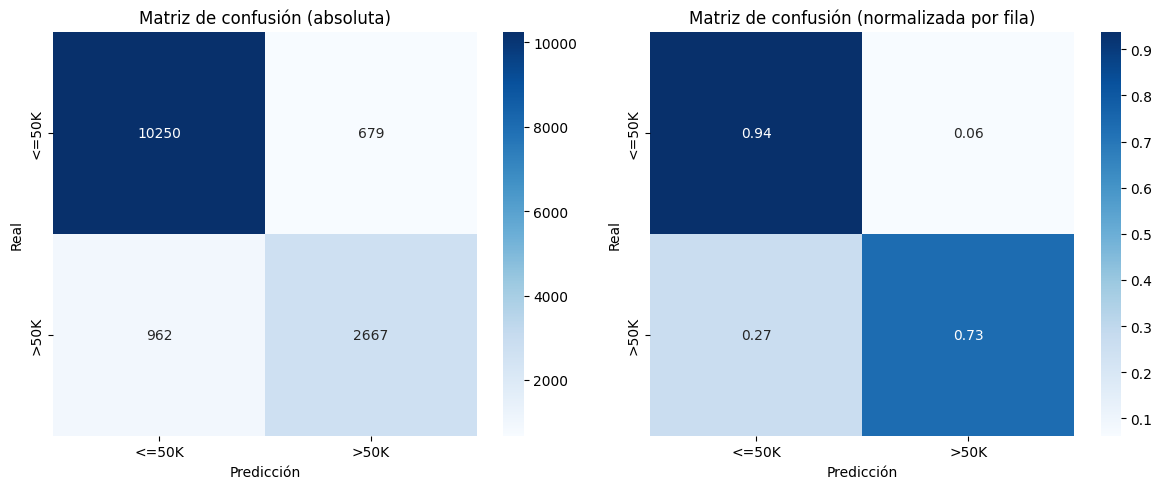

In [46]:
# Classification report + matrices de confusión — R3 (OHE, sin pos_weight)
model7.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader_c:
        logits = model7(x.to(device)).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Epoch  10 | Train acc=0.8665 f1=0.8376 loss=0.4427 | Val acc=0.8394 f1=0.8102 loss=0.4779
Early stopping en epoch 14 | mejor val_loss=0.4679 @ epoch 7
Pesos restaurados al mejor epoch (7, val_loss=0.4679)


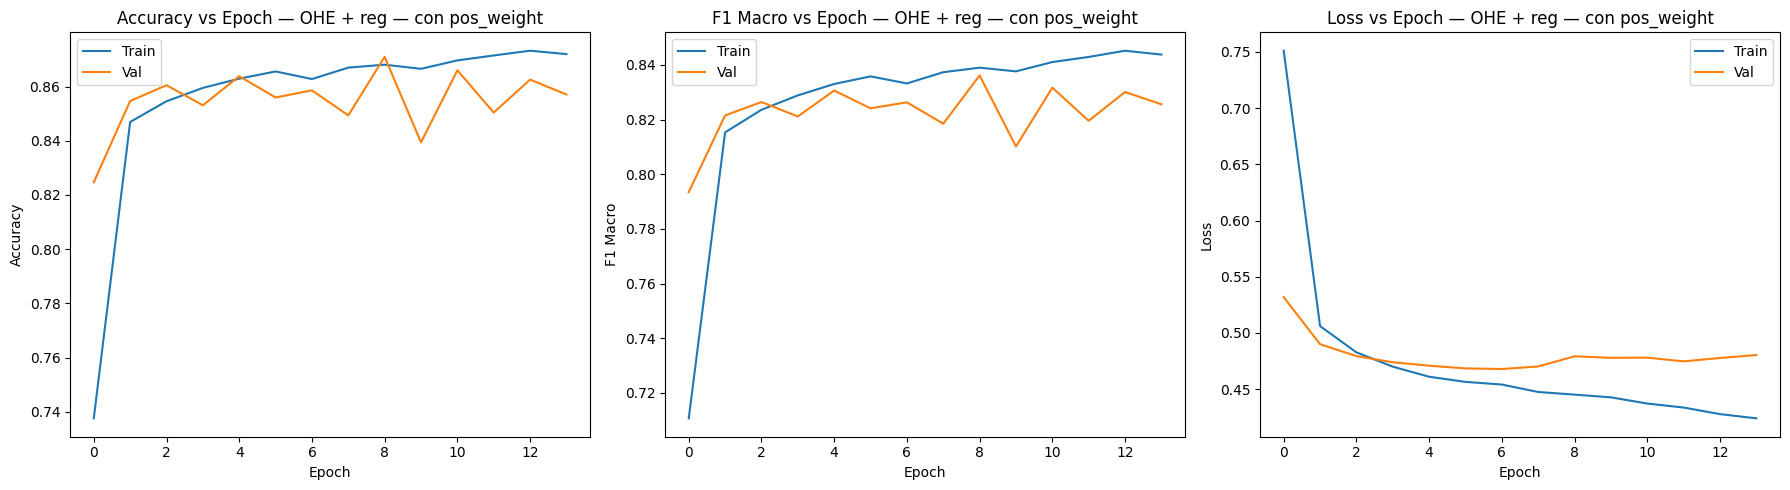

In [47]:
# === Experimento R4: OHE, con pos_weight (weight decay + early stopping) ===
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)
_g.manual_seed(SEED)

model8 = IncomeModelOHE(input_dim=X_train_c.shape[1]).to(device)
criterion8 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer8 = torch.optim.AdamW(model8.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)

history8 = fit_model(
    model8,
    criterion8,
    optimizer8,
    train_loader_c,
    val_loader_c,
    run_epoch_ohe,
    epochs=EPOCHS,
    patience=PATIENCE,
)
plot_history(history8, "OHE + reg — con pos_weight")

              precision    recall  f1-score   support

       <=50K       0.95      0.86      0.90     10929
        >50K       0.67      0.86      0.75      3629

    accuracy                           0.86     14558
   macro avg       0.81      0.86      0.83     14558
weighted avg       0.88      0.86      0.86     14558



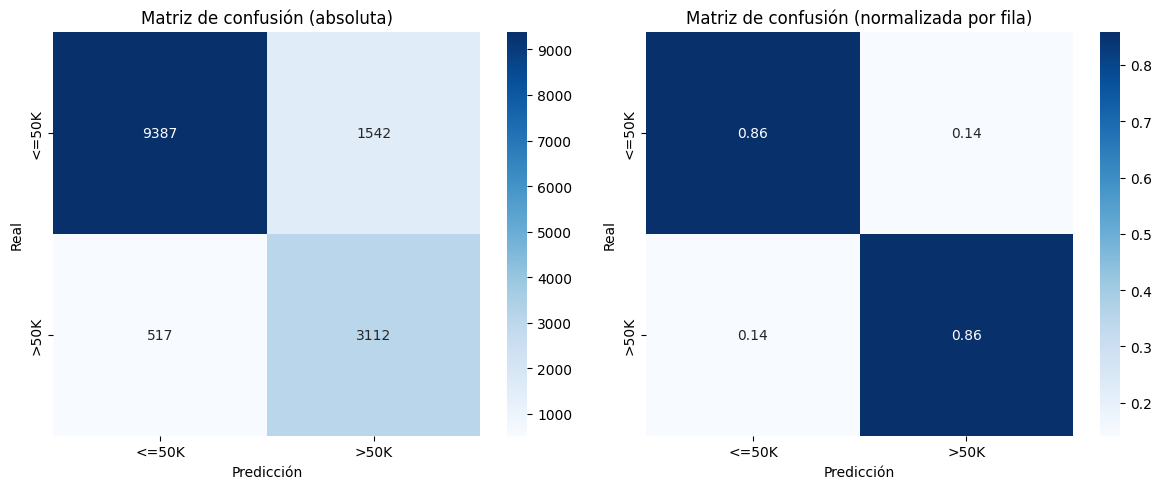

In [48]:
# Classification report + matrices de confusión — R4 (OHE, con pos_weight)
model8.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader_c:
        logits = model8(x.to(device)).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

### Comparación: baseline vs. regularizado

Al comparar estas curvas con las de Exp1–Exp4 se observa que:

- La loss de validación deja de divergir: en lugar de subir tras el epoch ~5–8, se mantiene plana / cercana a su mínimo, y el early stopping corta el entrenamiento antes de que el modelo se sobreajuste (restaurando los pesos del mejor epoch).
- La **brecha train/val** (en _loss_, _accuracy_ y F1 macro) se reduce respecto al baseline.
- El modelo final reportado ya no es el del epoch 50 sino el de mejor `val_loss`, por lo que las métricas de validación reflejan mejor la generalización real.


In [49]:
# Tabla comparativa: baseline (Exp1-4) vs. regularizado (R1-R4)
# Helpers self-contained (los de la seccion d) se definen mas abajo en el notebook).
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np
import pandas as pd


def _get_metrics(labels, preds):
    rep = classification_report(
        labels, preds, target_names=["<=50K", ">50K"], output_dict=True
    )
    return {
        "Accuracy (val)": round(accuracy_score(labels, preds), 4),
        "F1-Macro (val)": round(f1_score(labels, preds, average="macro"), 4),
        "Prec <=50K": round(rep["<=50K"]["precision"], 4),
        "Recall <=50K": round(rep["<=50K"]["recall"], 4),
        "F1 <=50K": round(rep["<=50K"]["f1-score"], 4),
        "Prec >50K": round(rep[">50K"]["precision"], 4),
        "Recall >50K": round(rep[">50K"]["recall"], 4),
        "F1 >50K": round(rep[">50K"]["f1-score"], 4),
    }


def _preds_emb(model, loader):
    model.eval()
    ps, ls = [], []
    with torch.no_grad():
        for x_d, x_o, x_c, x_s, x_e, y in loader:
            lg = model(
                x_d.to(device),
                x_o.to(device),
                x_c.to(device),
                x_s.to(device),
                x_e.to(device),
            ).squeeze(1)
            ps.extend((torch.sigmoid(lg) > 0.5).cpu().int().tolist())
            ls.extend(y.int().tolist())
    return ls, ps


def _preds_ohe(model, loader):
    model.eval()
    ps, ls = [], []
    with torch.no_grad():
        for x, y in loader:
            lg = model(x.to(device)).squeeze(1)
            ps.extend((torch.sigmoid(lg) > 0.5).cpu().int().tolist())
            ls.extend(y.int().tolist())
    return ls, ps


# (nombre, modelo, tipo_forward, loader, history, es_regularizado)
# Cada baseline va seguido de su par regularizado para comparar fila a fila.
configs = [
    ("Emb Exp1 (sin pw)", model1, "emb", val_loader, history1, False),
    ("Emb R1  (sin pw)", model5, "emb", val_loader, history5, True),
    ("Emb Exp2 (con pw)", model2, "emb", val_loader, history2, False),
    ("Emb R2  (con pw)", model6, "emb", val_loader, history6, True),
    ("OHE Exp3 (sin pw)", model3, "ohe", val_loader_c, history3, False),
    ("OHE R3  (sin pw)", model7, "ohe", val_loader_c, history7, True),
    ("OHE Exp4 (con pw)", model4, "ohe", val_loader_c, history4, False),
    ("OHE R4  (con pw)", model8, "ohe", val_loader_c, history8, True),
]

records = {}
for name, model, kind, loader, hist, regularizado in configs:
    labels, preds = (_preds_emb if kind == "emb" else _preds_ohe)(model, loader)
    # Epoch cuyos pesos tiene el modelo: el de mejor val_loss si hubo early
    # stopping (R1-R4), o el ultimo (epoch 50) en el baseline.
    idx = (
        int(np.argmin(hist["val_loss"])) if regularizado else len(hist["val_loss"]) - 1
    )
    records[name] = {
        "Tipo": "Regularizado" if regularizado else "Baseline",
        **_get_metrics(labels, preds),
        "Epoch modelo": idx + 1,
        "Epochs corridos": len(hist["val_loss"]),
        "Gap F1 train-val": round(hist["train_f1"][idx] - hist["val_f1"][idx], 4),
    }

df_comp_reg = pd.DataFrame(records).T
df_comp_reg

,Tipo,Accuracy (val),F1-Macro (val),Prec <=50K,Recall <=50K,F1 <=50K,Prec >50K,Recall >50K,F1 >50K,Epoch modelo,Epochs corridos,Gap F1 train-val
Emb Exp1 (sin pw),Baseline,0.8801,0.836,0.9107,0.9317,0.9211,0.779,0.7247,0.7509,50,50,0.0333
Emb R1 (sin pw),Regularizado,0.8849,0.8422,0.9128,0.9361,0.9243,0.7916,0.7308,0.76,16,23,0.0093
Emb Exp2 (con pw),Baseline,0.8531,0.8203,0.9463,0.8528,0.8971,0.6583,0.8542,0.7436,50,50,0.033
Emb R2 (con pw),Regularizado,0.8485,0.8176,0.9533,0.8392,0.8927,0.6441,0.8763,0.7425,16,23,0.0185
OHE Exp3 (sin pw),Baseline,0.8731,0.8277,0.9092,0.9231,0.9161,0.7573,0.7222,0.7394,50,50,0.0705
OHE R3 (sin pw),Regularizado,0.8873,0.8453,0.9142,0.9379,0.9259,0.7971,0.7349,0.7647,7,14,0.0032
OHE Exp4 (con pw),Baseline,0.8531,0.8174,0.9366,0.8628,0.8982,0.666,0.8242,0.7367,50,50,0.0669
OHE R4 (con pw),Regularizado,0.8586,0.8263,0.9478,0.8589,0.9012,0.6687,0.8575,0.7514,7,14,0.0069


Viendo estos resultados podemos ver que se redujo el overfitting (también se puede ver en las gráficas) para las cuatro configuraciones: el gap f1 train-val se redujo considerablemente.

Los modelos OHE fueron los más beneficiados ya que no tenían dropout desde un inicio y eran los más sobreajustados. El mejor modelo fue OHE R3 (sin pos_weight) lo que indica que los embeddings no aportaron una ventaja clara sobre one hot encoding.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.


In [50]:
from sklearn.metrics import classification_report, accuracy_score, f1_score


def get_report(labels, preds):
    rep = classification_report(
        labels, preds, target_names=["<=50K", ">50K"], output_dict=True
    )
    return {
        "Accuracy (val)": round(accuracy_score(labels, preds), 4),
        "F1-Macro (val)": round(f1_score(labels, preds, average="macro"), 4),
        "Prec <=50K": round(rep["<=50K"]["precision"], 4),
        "Recall <=50K": round(rep["<=50K"]["recall"], 4),
        "F1 <=50K": round(rep["<=50K"]["f1-score"], 4),
        "Prec >50K": round(rep[">50K"]["precision"], 4),
        "Recall >50K": round(rep[">50K"]["recall"], 4),
        "F1 >50K": round(rep[">50K"]["f1-score"], 4),
    }


def preds_emb(model, loader):
    model.eval()
    ps, ls = [], []
    with torch.no_grad():
        for x_d, x_o, x_c, x_s, x_e, y in loader:
            lg = model(
                x_d.to(device),
                x_o.to(device),
                x_c.to(device),
                x_s.to(device),
                x_e.to(device),
            ).squeeze(1)
            ps.extend((torch.sigmoid(lg) > 0.5).cpu().int().tolist())
            ls.extend(y.int().tolist())
    return ls, ps


def preds_ohe(model, loader):
    model.eval()
    ps, ls = [], []
    with torch.no_grad():
        for x, y in loader:
            lg = model(x.to(device)).squeeze(1)
            ps.extend((torch.sigmoid(lg) > 0.5).cpu().int().tolist())
            ls.extend(y.int().tolist())
    return ls, ps


l1, p1 = preds_emb(model1, val_loader)
l2, p2 = preds_emb(model2, val_loader)
l3, p3 = preds_ohe(model3, val_loader_c)
l4, p4 = preds_ohe(model4, val_loader_c)

configs = [
    ("Emb Exp1 (sin pw)", model1, l1, p1, 99, history1),
    ("Emb Exp2 (con pw)", model2, l2, p2, 99, history2),
    ("OHE Exp3 (sin pw)", model3, l3, p3, 166, history3),
    ("OHE Exp4 (con pw)", model4, l4, p4, 166, history4),
]

records = {}
for name, model, labels, preds, inp_dim, hist in configs:
    m = get_report(labels, preds)
    records[name] = {
        "Input dim": inp_dim,
        "Params totales": sum(p.numel() for p in model.parameters()),
        **m,
        "Gap F1 train-val": round(hist["train_f1"][-1] - hist["val_f1"][-1], 4),
    }

df_comp = pd.DataFrame(records).T
df_comp

,Input dim,Params totales,Accuracy (val),F1-Macro (val),Prec <=50K,Recall <=50K,F1 <=50K,Prec >50K,Recall >50K,F1 >50K,Gap F1 train-val
Emb Exp1 (sin pw),99.0,25280.0,0.8801,0.8360,0.9107,0.9317,0.9211,0.7790,0.7247,0.7509,0.0333
Emb Exp2 (con pw),99.0,25280.0,0.8531,0.8203,0.9463,0.8528,0.8971,0.6583,0.8542,0.7436,0.0330
OHE Exp3 (sin pw),166.0,29697.0,0.8731,0.8277,0.9092,0.9231,0.9161,0.7573,0.7222,0.7394,0.0705
OHE Exp4 (con pw),166.0,29697.0,0.8531,0.8174,0.9366,0.8628,0.8982,0.6660,0.8242,0.7367,0.0669


### Observaciones y conclusiones

#### 1. Overfitting: el diferenciador más relevante

La diferencia más marcada entre ambos enfoques no está en las métricas de validación en sí, sino en el **gap entre train y val**:

- **Modelos con embeddings**: gap F1 train-val de **0.03** (leve), indicando una buena generalización.
- **Modelos con OHE**: gap de **0.07–0.07**, casi el doble. El modelo OHE aprende bien los datos de entrenamiento pero esa ganancia no se transfiere al conjunto de validación.]

Factores que influyen en esta diferencia:

- **Dropout(0.3)** en el modelo de embeddings vs ninguna regularización en el OHE. No se puede atribuir la menor generalización solamente al encoding debido a que tampoco tenemos dropout en el modelo con OHE.

#### 2. Representación de features

El modelo OHE usa **67 dimensiones de entrada más (+68%)** y **4,417 parámetros adicionales (+17%)** respecto al modelo con embeddings, sin obtener mejor rendimiento. Los embeddings comprimen la información de 135 columnas OHE (14 + 41 + 80) en solo 68 dimensiones densas (7 + 21 + 40), logrando representaciones más compactas e informativas.

#### 3. Rendimiento global comparable, con ventaja consistente del embedding

La diferencia en F1-Macro es pequeña pero consistente: **0.84** (Emb Exp1) vs **0.83** (OHE Exp3). La ventaja es más pronunciada en la clase minoritaria: F1 >50K de **0.75** vs **0.73**.

#### 4. Representaciones semánticas vs representaciones fijas

Con OHE todas las categorias son igualmente distintas entre si, lo que es semánticamente incorrecto. Por ejemplo, `tech_programming_advanced` debería ser más similar a `tech_programming_basic` que a `finance_accounting_basic`. Los embeddings aprenden estas relaciones directamente desde los datos.

#### 5. Comportamiento ante el desbalance (pos_weight)

Ambos modelos responden de manera análoga al `pos_weight`: el recall de >50K sube ~0.11–0.13 puntos a expensas de la precisión (~0.12 de caída), sin cambio sustancial en F1-Macro. Este patrón es independiente del tipo de encoding y refleja el tradeoff entre recall y precisión propio de penalizar más los errores en la clase minoritaria durante el entrenamiento.

#### 6. Conclusión

Antes de dar las conclusiones menciono que mi experimentación implementando `L2 regularization` o `weight decay` junto con `Early Stopping` da resultados interesantes y eficientes, reduciendo el claro overfitting que sucedió en los apartados b y c, donde loss en val subia mientras que en training bajaba. En esta experimentación OHE con regularización sin pos_weight fue el mejor modelo encontrado. Esta experimentación no es parte de la consigna asi que las siguientes conclusiones se hacen solamente con lo encontrado en el apartado b y c.

A pesar de que ambos enfoques dan diferencias bastante sutiles, me voy por lo mas eficiente y simple.

El modelo con embeddings es el enfoque preferible para este problema por tres razones:

1. **Menor overfitting** (gap 0.03 vs 0.07+): las representaciones densas generalizan mejor, aunque parte del efecto se atribuye al Dropout presente solo en ese modelo.
2. **Mayor eficiencia**: logra igual o mejor rendimiento con menos parámetros y menor dimensionalidad de entrada, lo que escala favorablemente ante variables de alta cardinalidad.
3. **Representaciones semánticamente coherentes**: especialmente valiosas para `skill-profile` (80 categorías con agrupaciones naturales) y `native-country`.

El modelo OHE sería adecuado únicamente cuando: la cardinalidad de las variables es baja (< 10 categorías), las categorías son completamente nominales sin ninguna relación entre sí, o cuando la interpretabilidad directa de los pesos de entrada es un requisito del negocio.
